In [57]:
# All the imports at the start, cleaned up and organized

from collections import Counter

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from scipy import stats

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedShuffleSplit,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV,
    ShuffleSplit,
    learning_curve,
    cross_val_predict
)

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    accuracy_score,
    confusion_matrix,
    classification_report
)

from sklearn.utils.class_weight import compute_class_weight
from imblearn.pipeline import make_pipeline as imbalanced_make_pipeline
from imblearn.under_sampling import NearMiss

from xgboost import XGBClassifier





import time
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Def the load_data function to read the csv file and return a dataframe

def load_data(path):
    df=pd.read_csv(path)
    return df

df = load_data("./Data/creditcard.csv")

In [3]:
# First look into what the data looks like

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# More information about the data

print("Data info:")
df.isnull().sum().max()
df.info()
df.describe()

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21 

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [5]:
# Check the distribution Class for imbalance as warned in the description of the data.

print("Distribution of:",df["Class"].value_counts(normalize=True))


Distribution of: Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


Text(0, 0.5, 'Density')

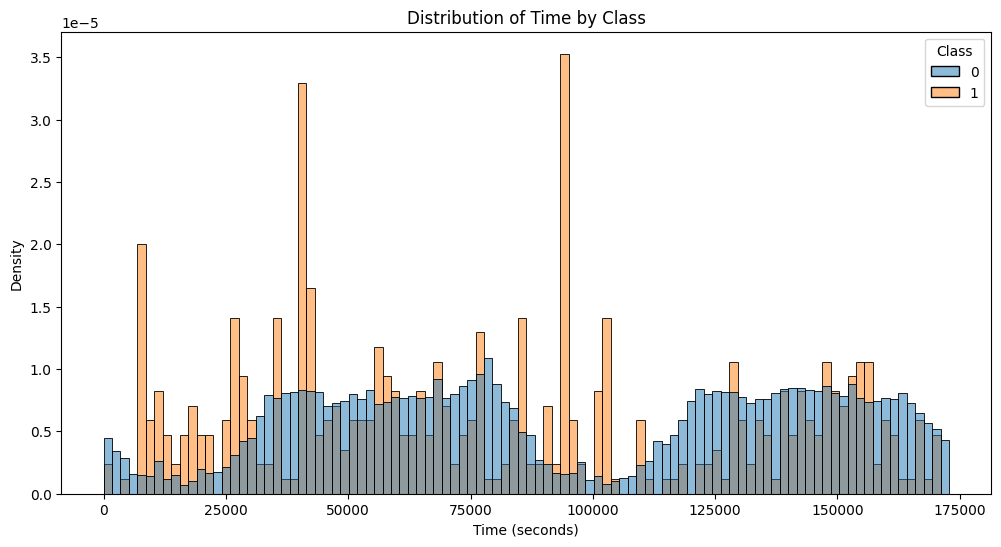

In [6]:
# Check to see if some obvious pattern emerge with the time and amount variables, since they are the only ones we can easily interpret.

plt.figure(figsize=(12,6))

sns.histplot(data=df, x="Time", hue="Class", bins=100, stat="density", common_norm=False)

plt.title("Distribution of Time by Class")
plt.xlabel("Time (seconds)")
plt.ylabel("Density")

Text(0, 0.5, 'Density')

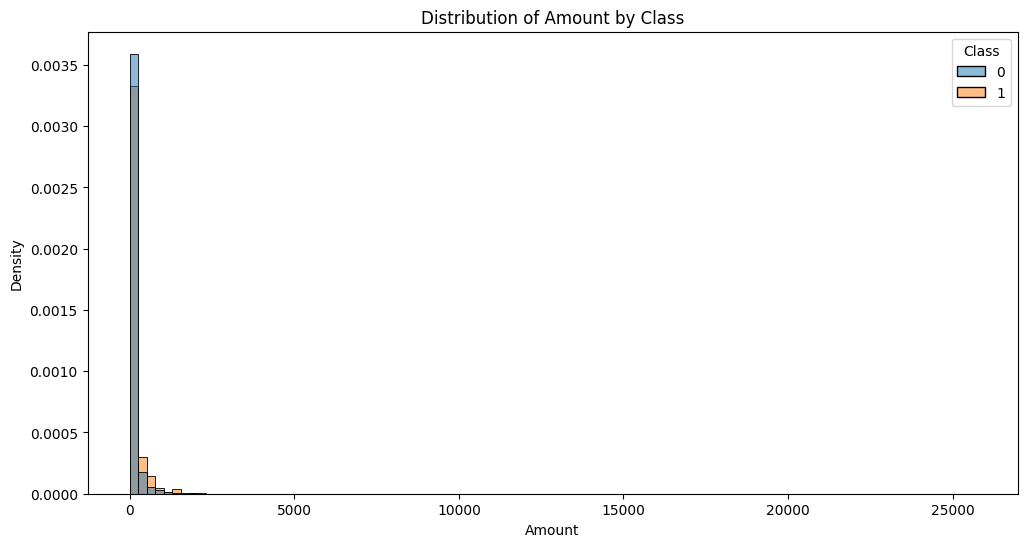

In [7]:
plt.figure(figsize=(12,6))

sns.histplot(data=df, x="Amount", hue="Class", bins=100, stat="density", common_norm=False)

plt.title("Distribution of Amount by Class")
plt.xlabel("Amount")
plt.ylabel("Density")

We immediately notice an issue with the density and the distribution due to outliers in the amount, for the sake of visual clarity, we will proceed to remove those to give a better view of this graph.

In [8]:
outlier_df = df[(np.abs(stats.zscore(df["Amount"])) < 3)]
outlier_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 280731 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    280731 non-null  float64
 1   V1      280731 non-null  float64
 2   V2      280731 non-null  float64
 3   V3      280731 non-null  float64
 4   V4      280731 non-null  float64
 5   V5      280731 non-null  float64
 6   V6      280731 non-null  float64
 7   V7      280731 non-null  float64
 8   V8      280731 non-null  float64
 9   V9      280731 non-null  float64
 10  V10     280731 non-null  float64
 11  V11     280731 non-null  float64
 12  V12     280731 non-null  float64
 13  V13     280731 non-null  float64
 14  V14     280731 non-null  float64
 15  V15     280731 non-null  float64
 16  V16     280731 non-null  float64
 17  V17     280731 non-null  float64
 18  V18     280731 non-null  float64
 19  V19     280731 non-null  float64
 20  V20     280731 non-null  float64
 21  V21     280731 

Text(0, 0.5, 'Density')

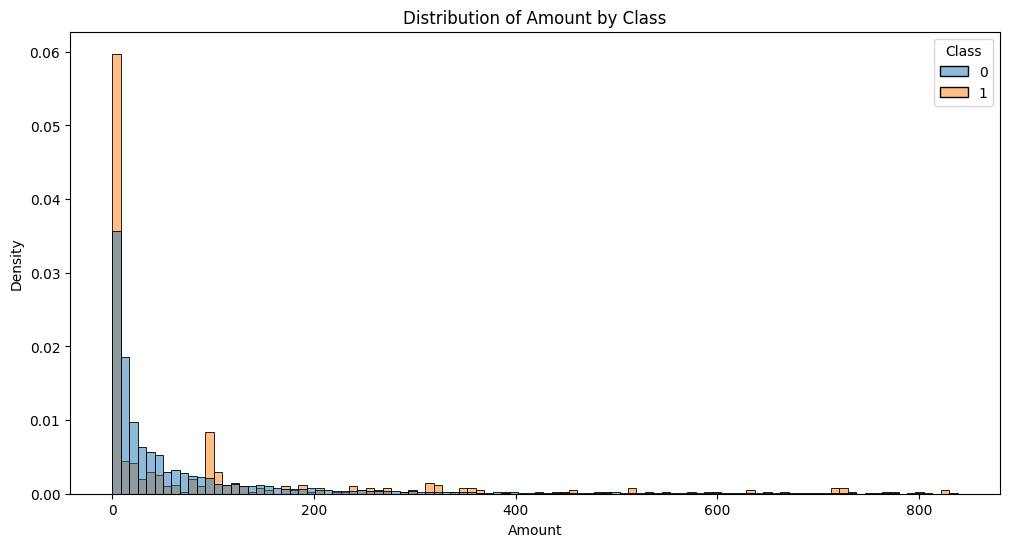

In [9]:
plt.figure(figsize=(12,6))

sns.histplot(data=outlier_df, x="Amount", hue="Class", bins=100, stat="density", common_norm=False)

plt.title("Distribution of Amount by Class")
plt.xlabel("Amount")
plt.ylabel("Density")

Here we have a much clearer view of the distribution thanks to removing outliers beyond 3 standard deviations.

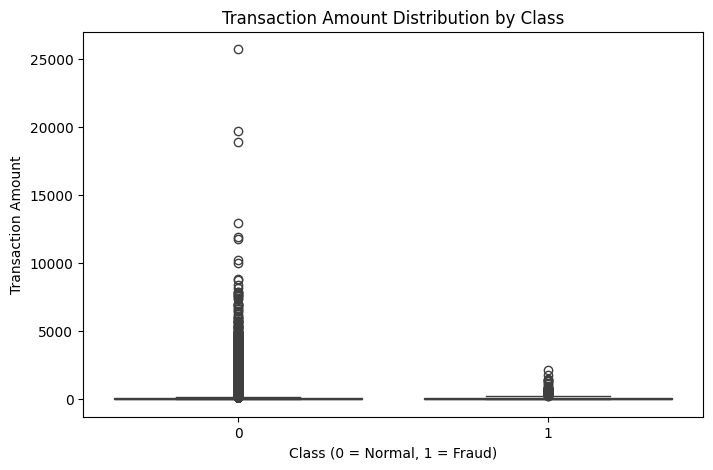

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount Distribution by Class")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Transaction Amount")

plt.show()

<Axes: xlabel='amount_bin'>

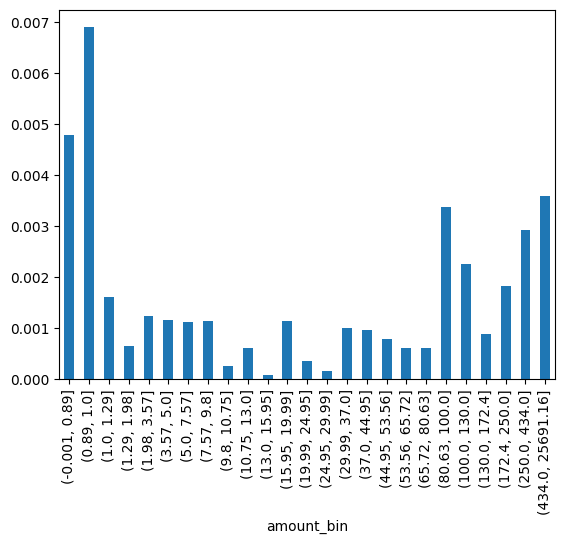

In [11]:
df_plot = df.copy()
df_plot["amount_bin"] = pd.qcut(df["Amount"], 25)

fraud_rate = df_plot.groupby("amount_bin")["Class"].mean()

fraud_rate.plot(kind="bar")

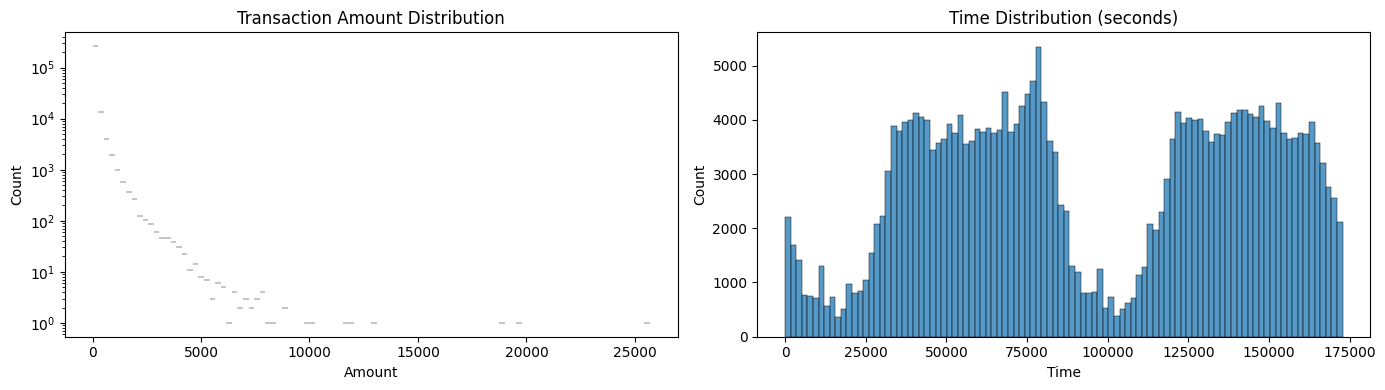

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


In [12]:
# Because we know the data is imbalanced, another way to look at it is to use a log scale to be able to see the distribution of the amounts for both classes.

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["Amount"], bins=100, ax=axes[0], log_scale=(False, True))
axes[0].set_title("Transaction Amount Distribution")

sns.histplot(df["Time"], bins=100, ax=axes[1])
axes[1].set_title("Time Distribution (seconds)")

plt.tight_layout()
plt.show()

# Fraud vs legit Amount:
df.groupby("Class")["Amount"].describe()

<Axes: xlabel='Class', ylabel='log_amount'>

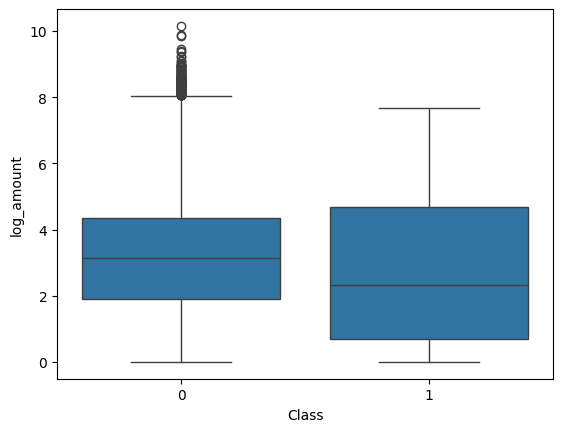

In [13]:
df_plot["log_amount"] = np.log1p(df["Amount"])

sns.boxplot(data=df_plot, x="Class", y="log_amount")

Now that we have an idea of how the human-readable features look like, we can try to see if there are patterns that appear among the anonimized data (V1 to V28)

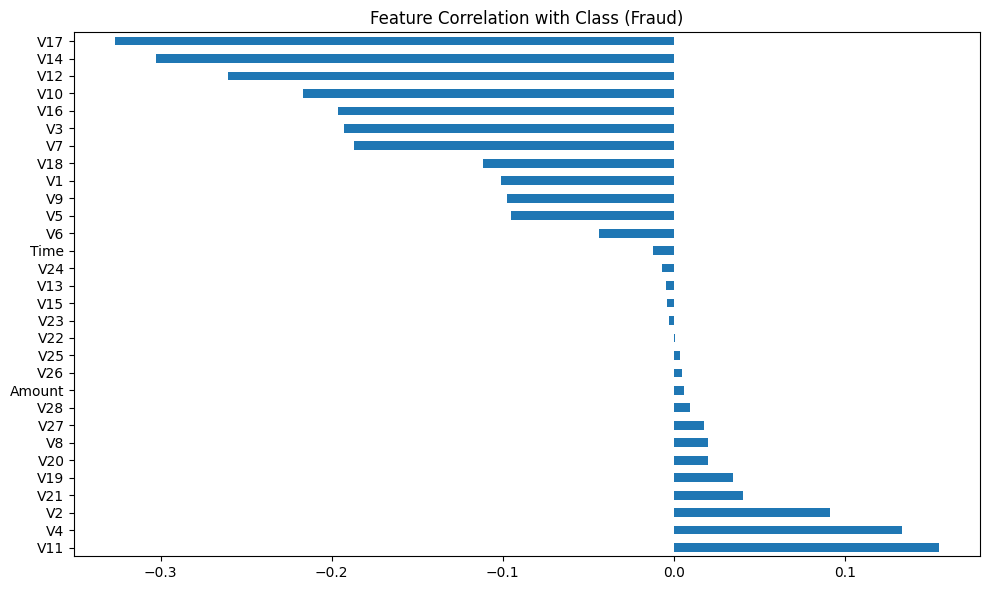

In [14]:
corr = df.corr()["Class"].sort_values(ascending=False)
plt.figure(figsize=(10, 6))
corr.drop("Class").plot(kind="barh")
plt.title("Feature Correlation with Class (Fraud)")
plt.tight_layout()
plt.show()

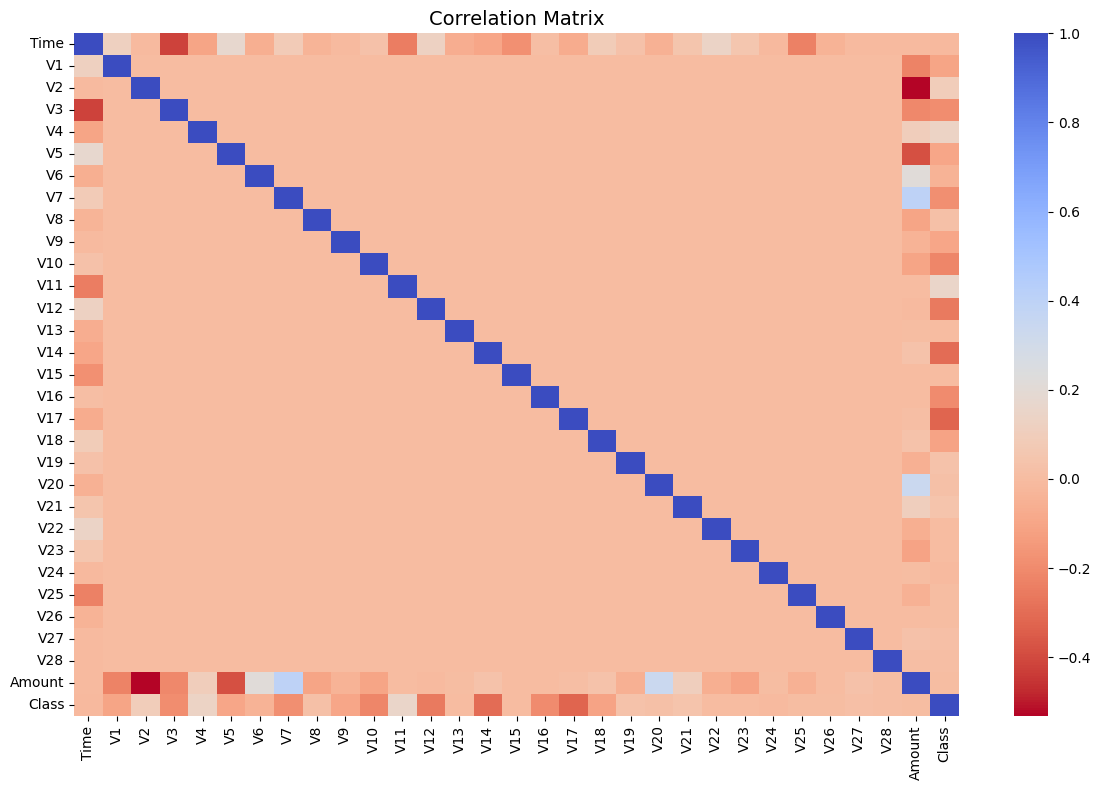

In [15]:
# Make a single correlation heatmap for the full dataset
plt.figure(figsize=(12, 8))

corr = df.corr()
sns.heatmap(corr, cmap="coolwarm_r", annot=False)
plt.title("Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()


V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
Name: Class, dtype: float64


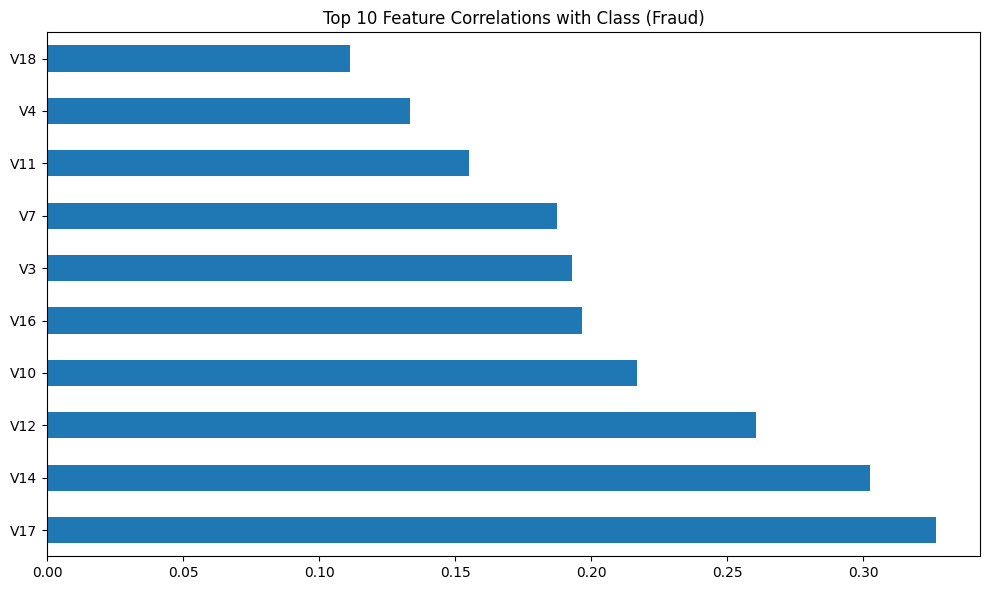

In [16]:
corr = df.corr()["Class"].drop("Class").abs().sort_values(ascending=False)
top_corr = corr.head(10)
print(top_corr)
plt.figure(figsize=(10, 6))
top_corr.plot(kind="barh")
plt.title("Top 10 Feature Correlations with Class (Fraud)")
plt.tight_layout()
plt.show()

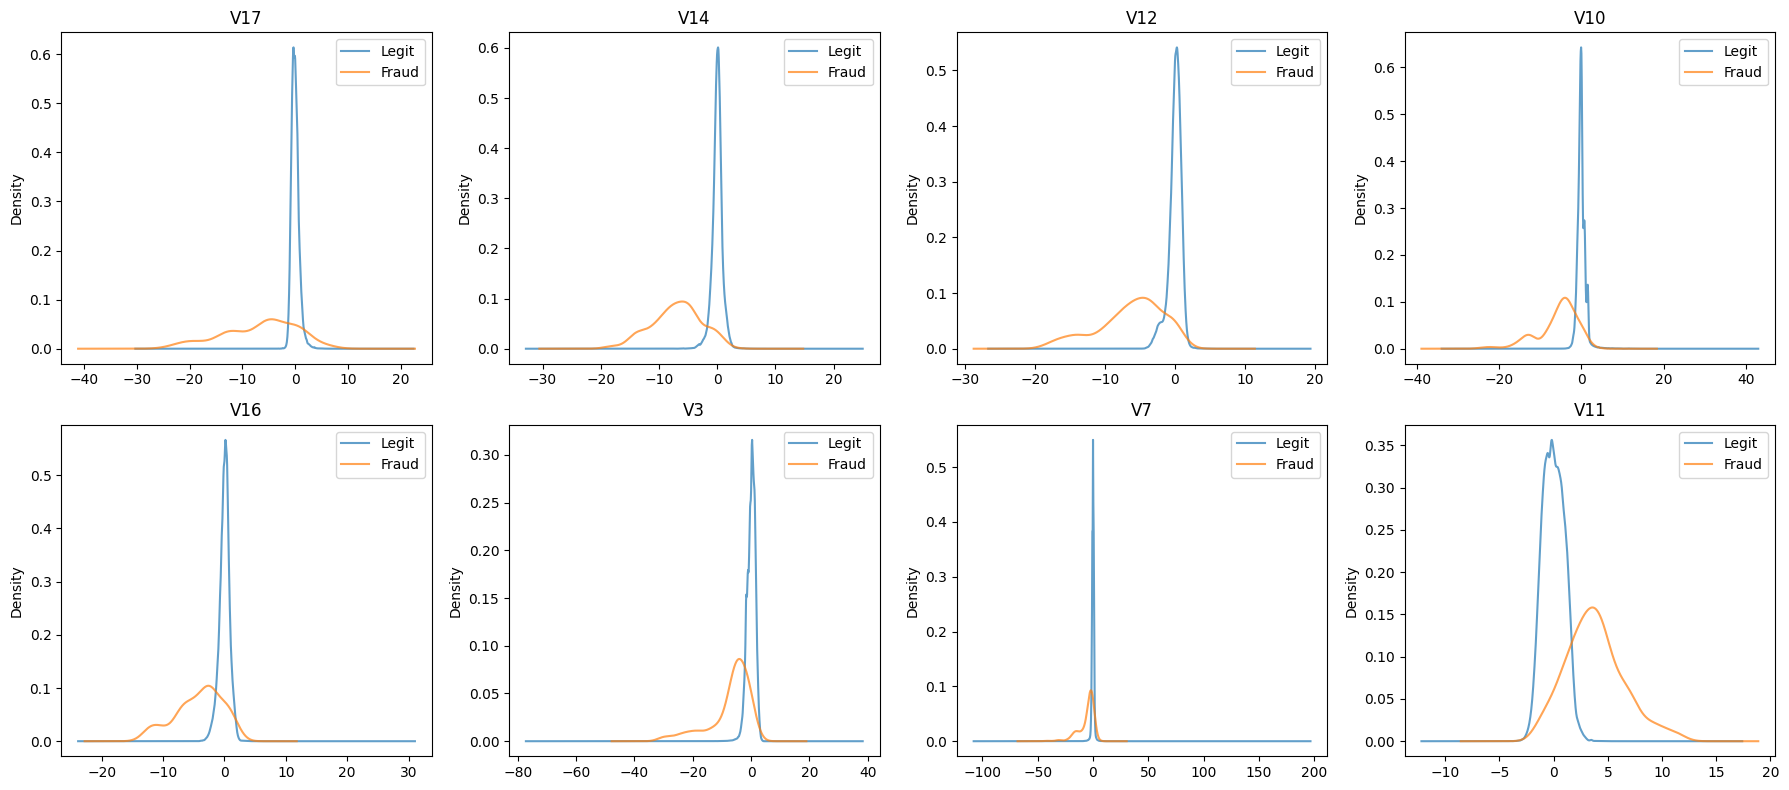

In [17]:
# Let"s try to see if the features with the highest correlation with the class show different distributions for fraud vs legit transactions. We can do this by plotting the KDE for each of the top features.

corr = df.corr()["Class"].drop("Class").sort_values()
top_features = corr.abs().nlargest(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, feat in zip(axes.flatten(), top_features):
    df[df["Class"] == 0][feat].plot(kind="kde", ax=ax, label="Legit", alpha=0.7)
    df[df["Class"] == 1][feat].plot(kind="kde", ax=ax, label="Fraud", alpha=0.7)
    ax.set_title(feat)
    ax.legend()
plt.tight_layout()
plt.show()

We can see here that there are indeed some correlation between data, however, due to how extremely skewed our data is, it is better to try and use a scaler, or even other methods such as undersampling, to have a better view of how data correlate between each other

In [18]:
df_scaled=df.copy()
rob_scaler = RobustScaler() #Using robust scaler because of the extreme outliers

rob_scaler_amount = RobustScaler()
rob_scaler_time = RobustScaler()


df_scaled["scaled_amount"]=rob_scaler_amount.fit_transform(df_scaled["Amount"].values.reshape(-1,1))
df_scaled["scaled_time"]=rob_scaler_time.fit_transform(df_scaled["Time"].values.reshape(-1,1))

df_scaled.drop(["Time","Amount"], axis=1, inplace=True)


# For readability we can move the scaled amount and time to the front of the dataframe
scaled_amount = df_scaled["scaled_amount"]
scaled_time = df_scaled["scaled_time"]

df_scaled.drop(["scaled_amount", "scaled_time"], axis=1, inplace=True)
df_scaled.insert(0, "scaled_amount", scaled_amount)
df_scaled.insert(1, "scaled_time", scaled_time)

df_scaled.head()

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.783274,-0.994983,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.269825,-0.994983,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.983721,-0.994972,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.418291,-0.994972,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,0.670579,-0.994960,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


In [19]:
X = df_scaled.drop("Class", axis=1)
y = df_scaled["Class"]


skf = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
for train_index, test_index in skf.split(X, y):
    ori_X_train, ori_X_test = X.iloc[train_index], X.iloc[test_index]
    ori_y_train, ori_y_test = y.iloc[train_index], y.iloc[test_index]
    
# Turn into an array
original_Xtrain = ori_X_train.values
original_Xtest = ori_X_test.values
original_ytrain = ori_y_train.values
original_ytest = ori_y_test.values

# See if both the train and test label distribution are similarly distributed
train_unique_label, train_counts_label = np.unique(original_ytrain, return_counts=True)
test_unique_label, test_counts_label = np.unique(original_ytest, return_counts=True)
print("-" * 100)

print("Label Distributions: \n")
print(train_counts_label/ len(original_ytrain))
print(test_counts_label/ len(original_ytest))

----------------------------------------------------------------------------------------------------
Label Distributions: 

[0.99827075 0.00172925]
[0.99827955 0.00172045]


In [20]:
df_scaled_balanced = df_scaled.copy()
df_scaled_balanced = df_scaled_balanced.sample(frac=1, random_state=42)

In [21]:
df_scaled_balanced.value_counts("Class")

Class
0    284315
1       492
Name: count, dtype: int64

Because of how skewed the dataset is, we"ll try to normalize it by making them equivalent to get a normal distribution

In [22]:
fraud_df = df_scaled.loc[df_scaled["Class"] == 1]
non_fraud_df = df_scaled.loc[df_scaled["Class"] == 0][:492]

normal_distributed_df = pd.concat([fraud_df, non_fraud_df], axis=0)
normal_distributed_df = normal_distributed_df.sample(frac=1, random_state=42)

normal_distributed_df.head()

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
121,-0.179976,-0.994079,-0.427191,0.745708,1.761811,-0.165130,0.058298,-0.213413,0.647323,0.073464,...,0.052828,-0.201681,-0.432070,0.013164,0.161606,-0.401310,0.047423,0.102549,-0.116571,0
248296,-0.307413,0.812780,-0.613696,3.698772,-5.534941,5.620486,1.649263,-2.335145,-0.907188,0.706362,...,0.354773,0.319261,-0.471379,-0.075890,-0.667909,-0.642848,0.070600,0.488410,0.292345,1
239,-0.027947,-0.993104,1.171439,0.474974,0.011761,1.264303,0.116234,-0.865986,0.554393,-0.276375,...,-0.119439,0.070051,0.278843,-0.097491,0.426278,0.744938,-0.274728,0.008472,0.015492,0
239501,3.007895,0.768888,-6.682832,-2.714268,-5.774530,1.449792,-0.661836,-1.148650,0.849686,0.433427,...,-1.928527,0.220526,1.187013,0.335821,0.215683,0.803110,0.044033,-0.054988,0.082337,1
143336,3.226717,0.006967,-6.713407,3.921104,-9.746678,5.148263,-5.151563,-2.099389,-5.937767,3.578780,...,0.135711,0.954272,-0.451086,0.127214,-0.339450,0.394096,1.075295,1.649906,-0.394905,1


Distribution of: Class
0    0.5
1    0.5
Name: proportion, dtype: float64


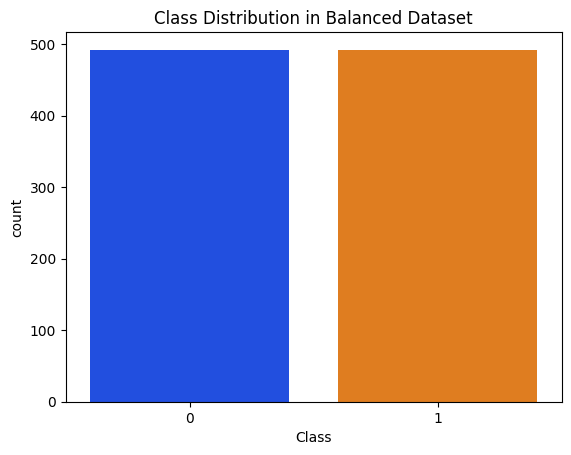

In [23]:
print("Distribution of:",normal_distributed_df["Class"].value_counts(normalize=True))

sns.countplot(x="Class", data=normal_distributed_df, palette="bright")
plt.title("Class Distribution in Balanced Dataset")
plt.show()

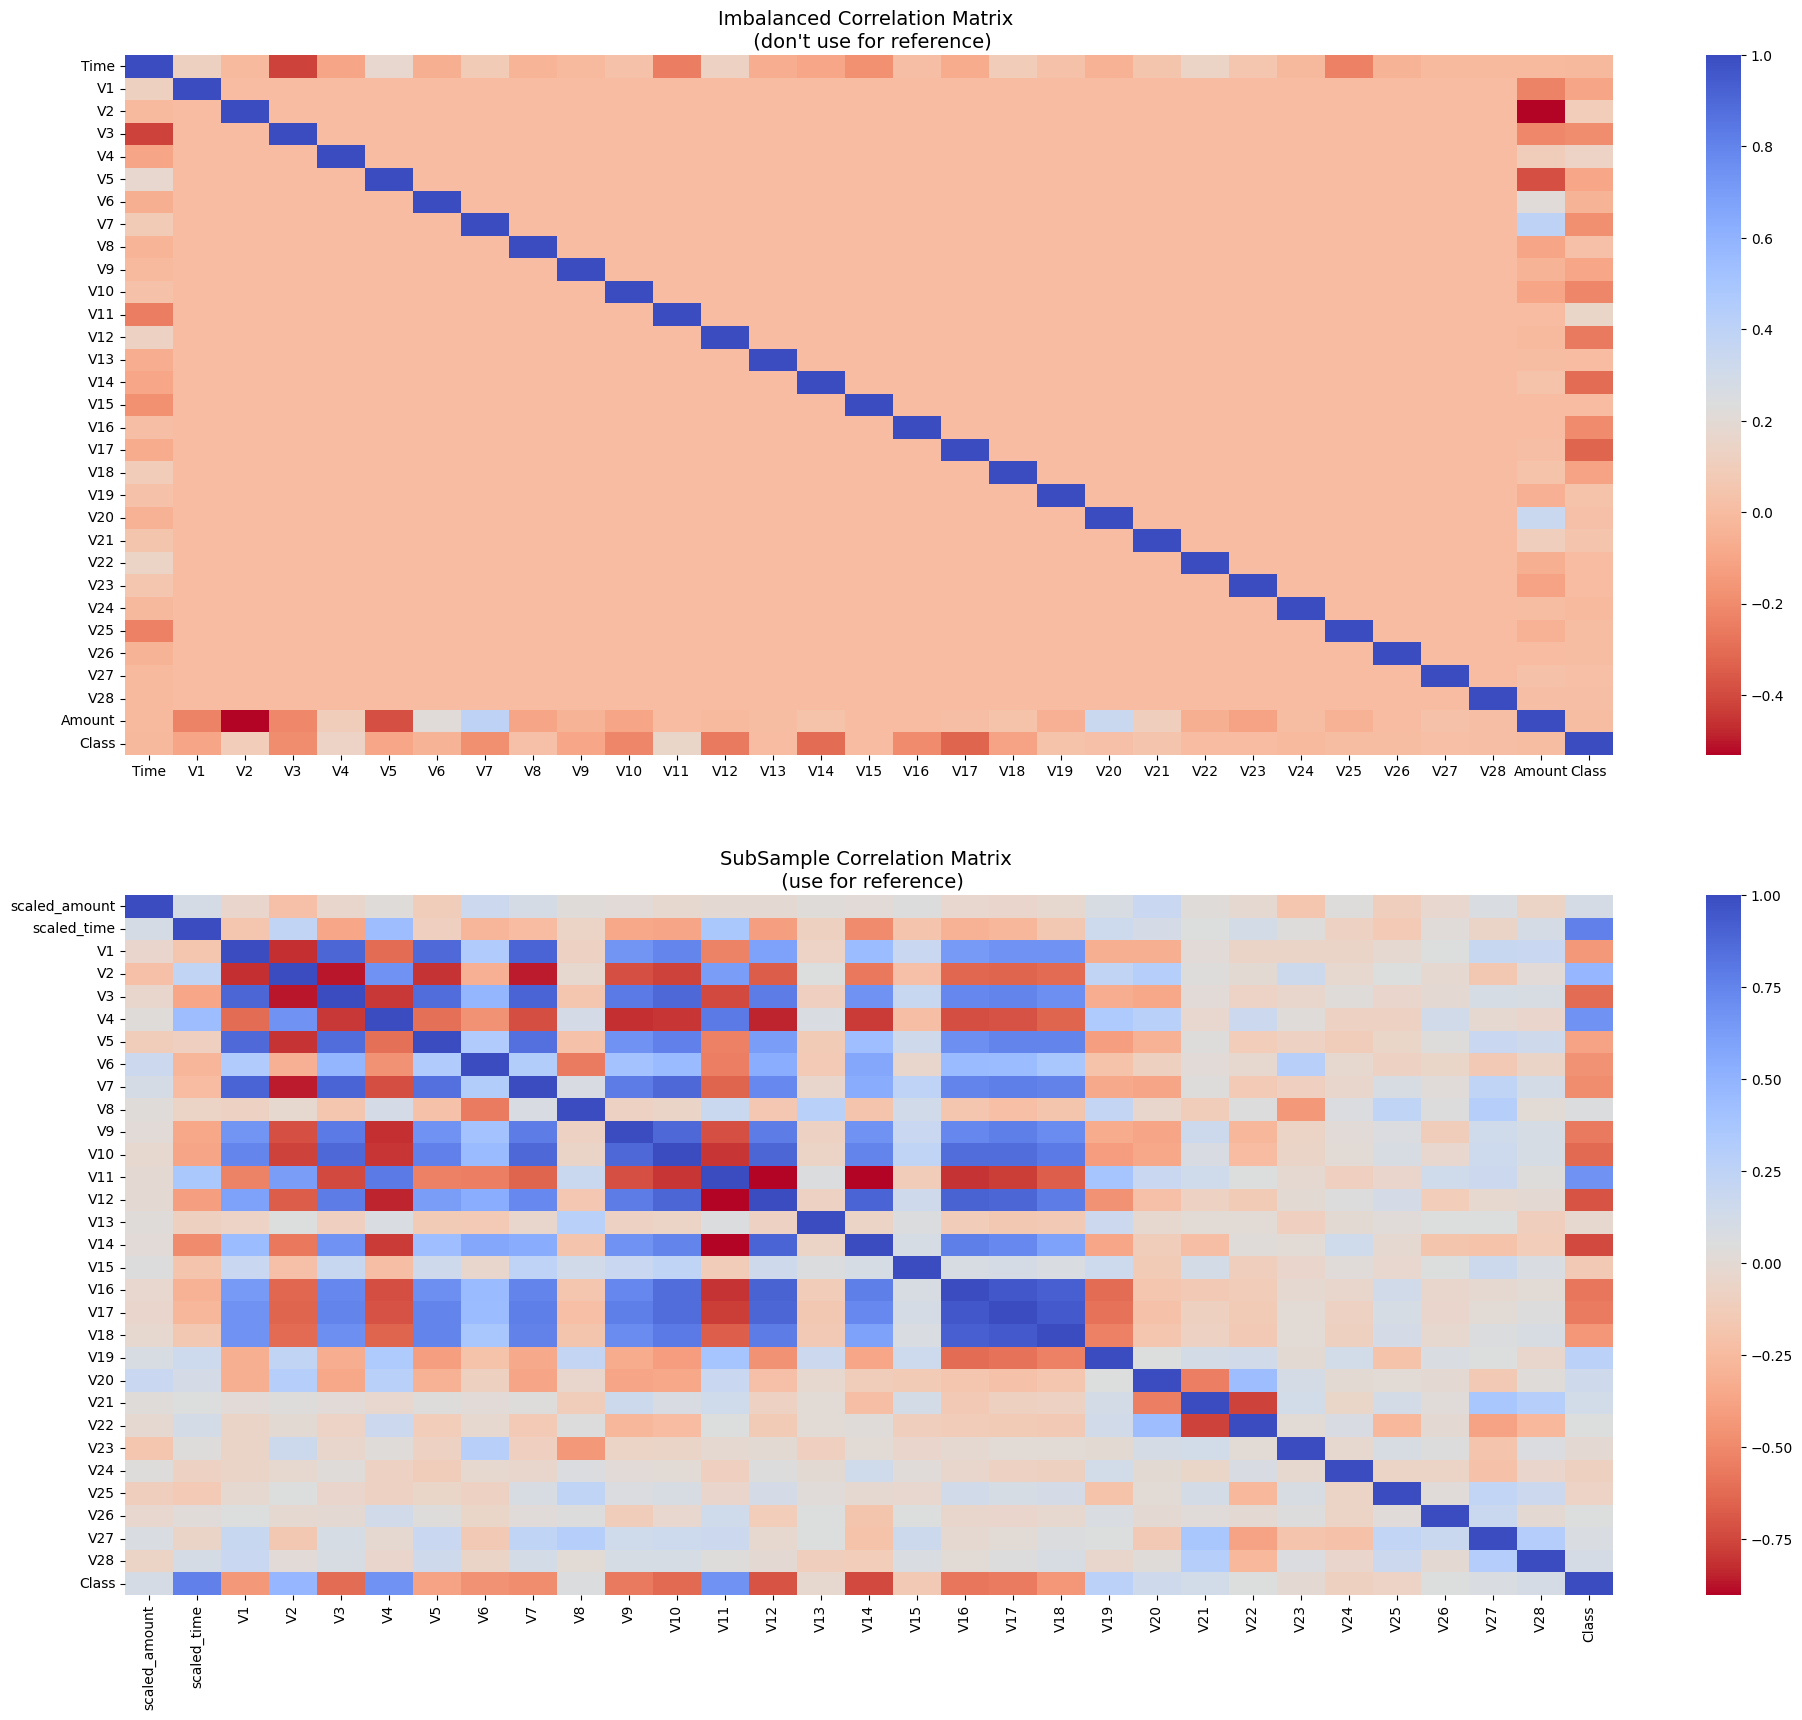

In [24]:
f, (ax1, ax2) = plt.subplots(2, 1, figsize=(24,20))

# Entire DataFrame
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm_r", annot_kws={"size":20}, ax=ax1)
ax1.set_title("Imbalanced Correlation Matrix \n (don't use for reference)", fontsize=14)


sub_sample_corr = normal_distributed_df.corr()
sns.heatmap(sub_sample_corr, cmap="coolwarm_r", annot_kws={"size":20}, ax=ax2)
ax2.set_title("SubSample Correlation Matrix \n (use for reference)", fontsize=14)
plt.show()

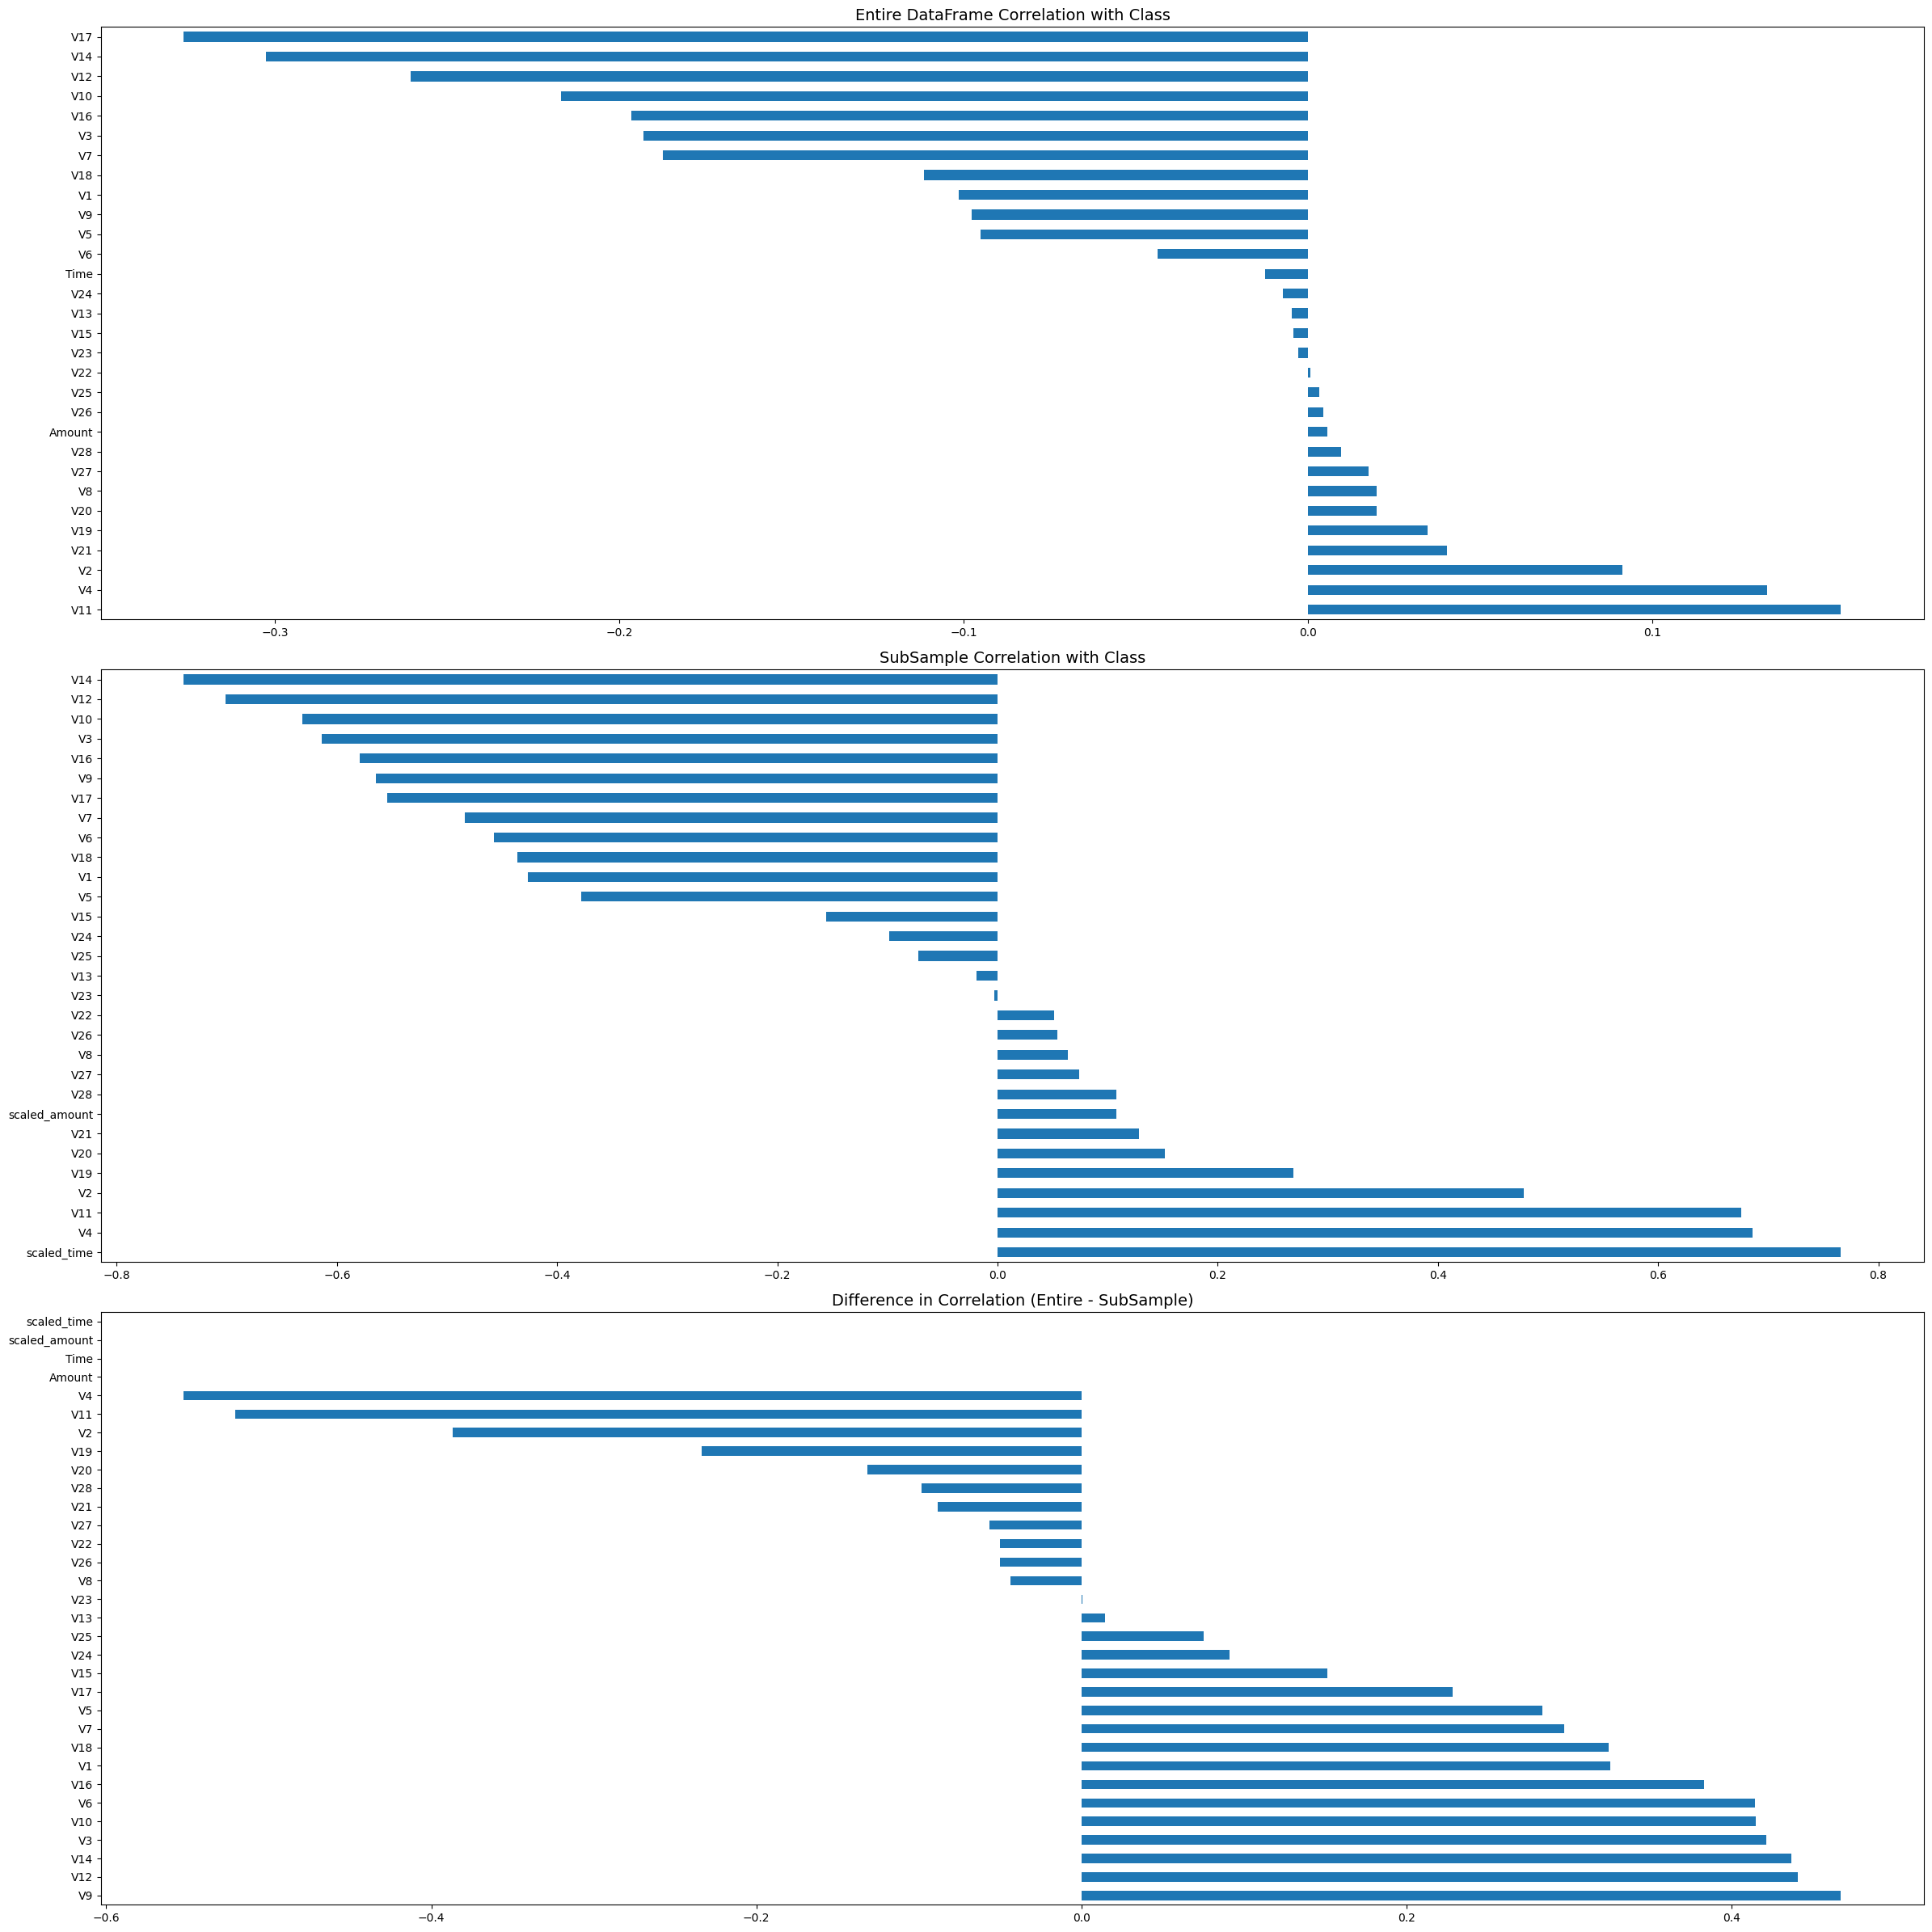

In [25]:
f, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(24, 24))


# Entire DataFrame
corr = df.corr()["Class"].sort_values(ascending=False)
corr.drop("Class").plot(kind="barh", ax=ax1)
ax1.set_title("Entire DataFrame Correlation with Class", fontsize=14)

# Sub-Sample DataFrame
sub_sample_corr = normal_distributed_df.corr()["Class"].sort_values(ascending=False)
sub_sample_corr.drop("Class").plot(kind="barh", ax=ax2)
ax2.set_title("SubSample Correlation with Class", fontsize=14)

corr_diff = corr - sub_sample_corr
corr_diff.drop("Class").sort_values(ascending=False).plot(kind="barh", ax=ax3)
ax3.set_title("Difference in Correlation (Entire - SubSample)", fontsize=14)

plt.tight_layout()
plt.show()

scaled_time    0.766175
V14            0.739062
V12            0.701195
V4             0.685672
V11            0.675408
V10            0.631532
V3             0.613963
V16            0.579323
V9             0.564955
V17            0.554530
Name: Class, dtype: float64
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
Name: Class, dtype: float64


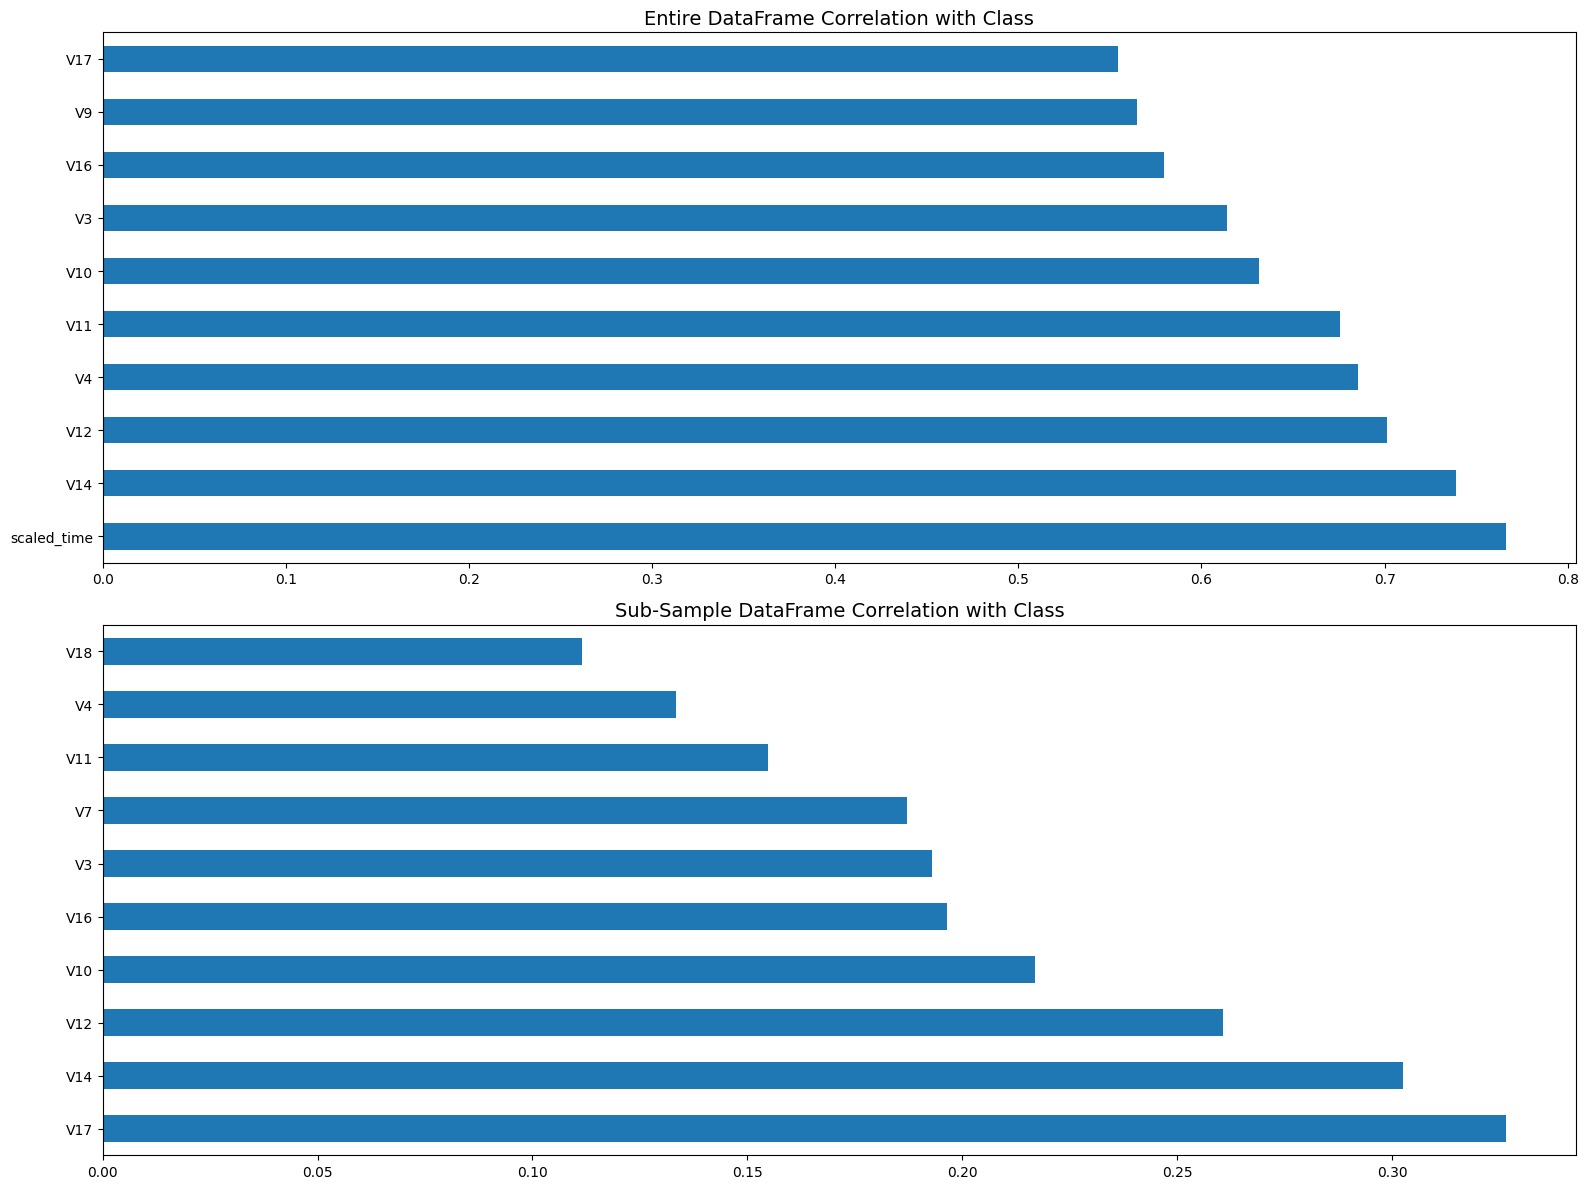

In [26]:
f, (ax1, ax2) = plt.subplots(2, 1, figsize=(16,12))

sub_sample_corr = normal_distributed_df.corr()["Class"].drop("Class").abs().sort_values(ascending=False)
top_corr_sample = sub_sample_corr.head(10)
print(top_corr_sample)
top_corr_sample.plot(kind="barh", ax=ax1)
ax1.set_title("Entire DataFrame Correlation with Class", fontsize=14)

corr = df.corr()["Class"].drop("Class").abs().sort_values(ascending=False)
top_corr = corr.head(10)
print(top_corr)
top_corr.plot(kind="barh", ax=ax2)
ax2.set_title("Sub-Sample DataFrame Correlation with Class", fontsize=14)
plt.tight_layout()
plt.show()

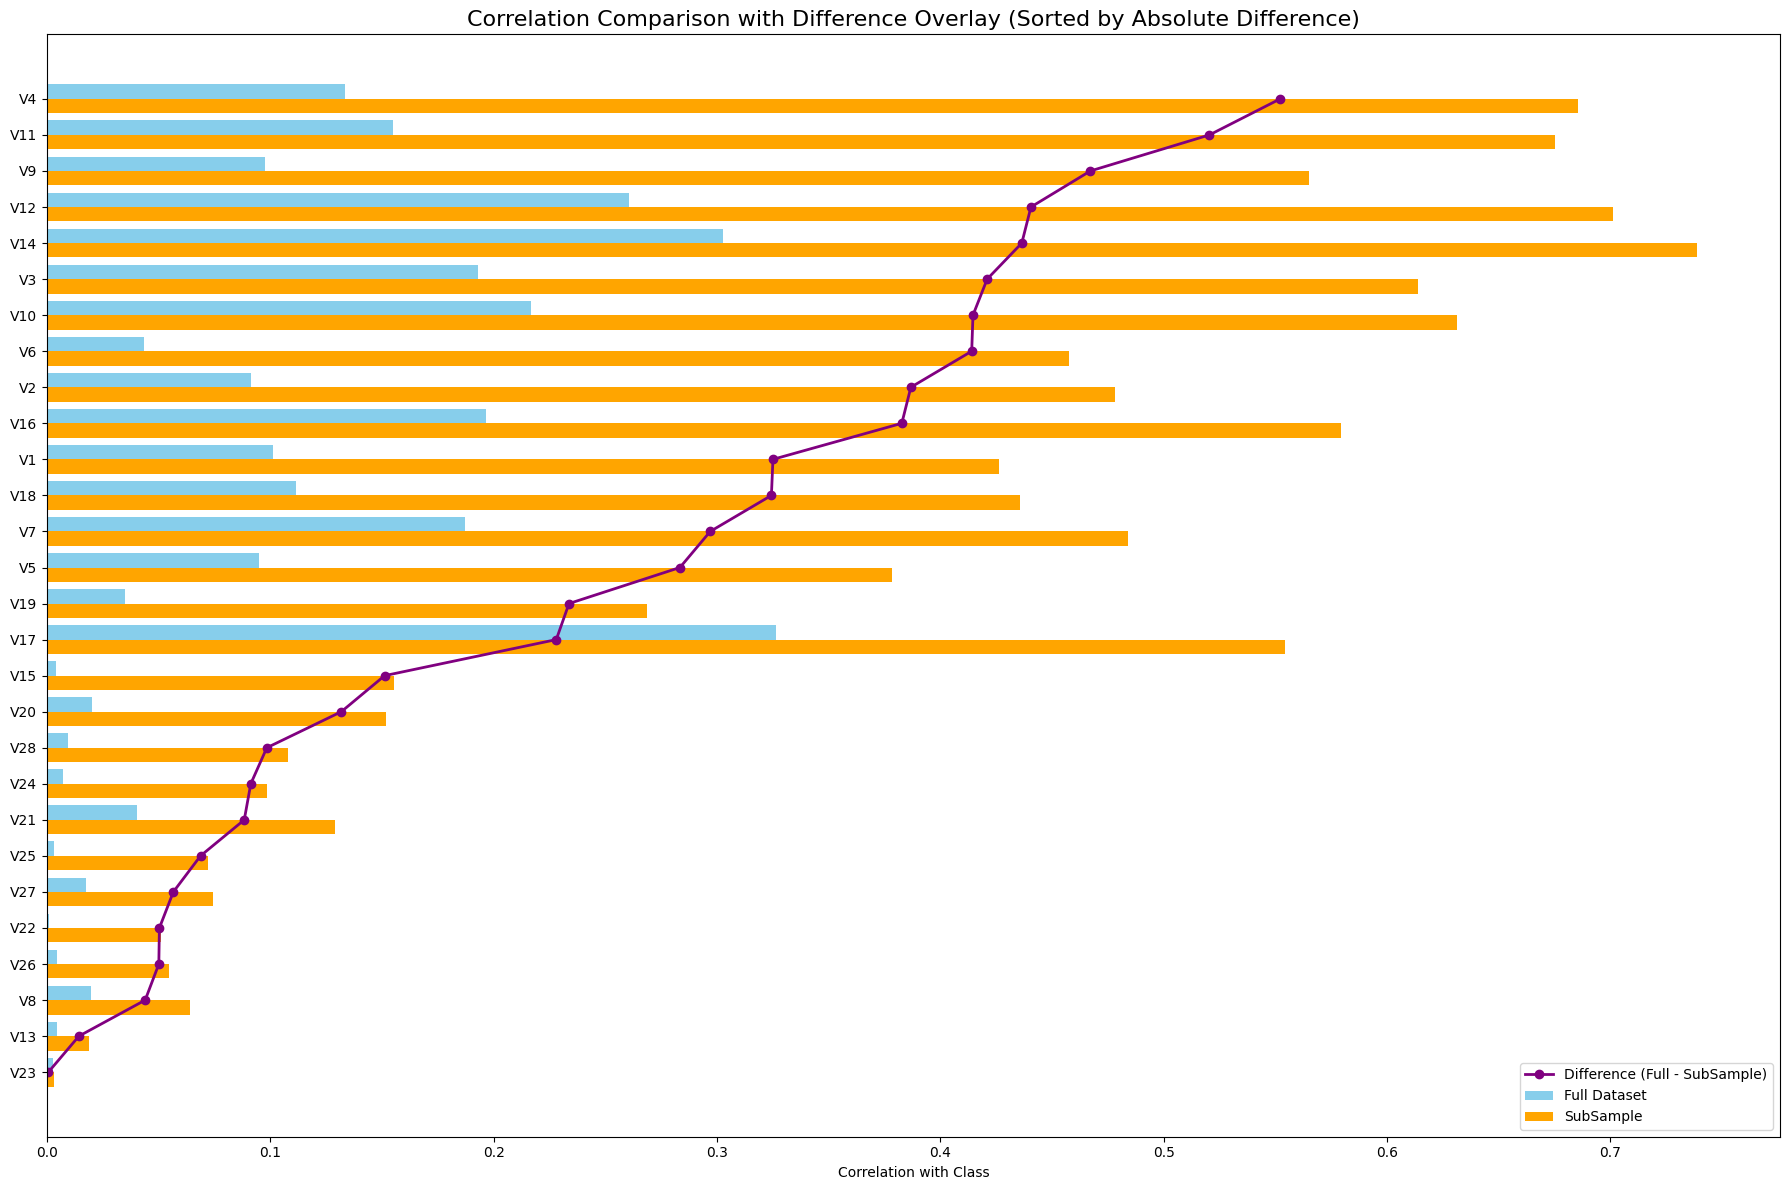

In [27]:
common_features = corr.index.intersection(sub_sample_corr.index)
corr_full_aligned = corr[common_features]
corr_sub_aligned = sub_sample_corr[common_features]

corr_diff = corr_full_aligned - corr_sub_aligned

abs_diff_order = corr_diff.abs().sort_values(ascending=False).index
corr_full_sorted = corr_full_aligned[abs_diff_order]
corr_sub_sorted = corr_sub_aligned[abs_diff_order]
corr_diff_sorted = corr_diff[abs_diff_order]

x = np.arange(len(abs_diff_order))
bar_width = 0.4

fig, ax = plt.subplots(figsize=(18, 12))

ax.barh(x - bar_width/2, corr_full_sorted.values, height=bar_width, label="Full Dataset", color="skyblue")
ax.barh(x + bar_width/2, corr_sub_sorted.values, height=bar_width, label="SubSample", color="orange")
ax.plot(corr_diff_sorted.values*-1, x, color="purple", marker="o", linestyle="-", linewidth=2, label="Difference (Full - SubSample)")

ax.set_yticks(x)
ax.set_yticklabels(abs_diff_order)

ax.set_xlabel("Correlation with Class")
ax.set_title("Correlation Comparison with Difference Overlay (Sorted by Absolute Difference)", fontsize=16)
ax.legend(loc="lower right")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

As we can see, undersampling results in a large difference in target-feature correlation compared to the raw dataset meaning that it will have a sizeable impact on the results we may get with any predictive models.

In [28]:
def remove_outliers(df, features, multiplier=2):
    for feat in features:
        fraud_vals = df.loc[df["Class"] == 1, feat]
        q25 = np.percentile(fraud_vals, 25)
        q75 = np.percentile(fraud_vals, 75)
        iqr = q75 - q25
        lower_bound = q25 - multiplier * iqr
        upper_bound = q75 + multiplier * iqr
        
        outliers = fraud_vals[(fraud_vals < lower_bound) | (fraud_vals > upper_bound)]
        print(f"{feat} | lower: {lower_bound:.4f} | upper: {upper_bound:.4f} | outliers: {len(outliers)}")
        
        df = df.drop(df[(df[feat] < lower_bound) | (df[feat] > upper_bound)].index)
        print(f"Rows remaining: {len(df)}\n")
        
    return df

normal_distributed_df = remove_outliers(normal_distributed_df, top_features)

V17 | lower: -33.1513 | upper: 19.8643 | outliers: 0
Rows remaining: 984

V14 | lower: -20.5125 | upper: 6.5370 | outliers: 0
Rows remaining: 984

V12 | lower: -20.1164 | upper: 8.4541 | outliers: 0
Rows remaining: 984

V10 | lower: -18.0417 | upper: 7.6708 | outliers: 11
Rows remaining: 972

V16 | lower: -16.7546 | upper: 9.2131 | outliers: 0
Rows remaining: 972

V3 | lower: -20.3308 | upper: 9.8644 | outliers: 29
Rows remaining: 943

V7 | lower: -15.6451 | upper: 9.0611 | outliers: 20
Rows remaining: 923

V11 | lower: -4.2871 | upper: 11.0219 | outliers: 7
Rows remaining: 916



In [29]:
# New_df is from the random undersample data (fewer instances)
X = normal_distributed_df.drop("Class", axis=1)
y = normal_distributed_df["Class"]


# T-SNE Implementation
t0 = time.time()
X_reduced_tsne = TSNE(n_components=2, random_state=42).fit_transform(X.values)
t1 = time.time()
print("T-SNE took {:.2} s".format(t1 - t0))

# PCA Implementation
t0 = time.time()
X_reduced_pca = PCA(n_components=2, random_state=42).fit_transform(X.values)
t1 = time.time()
print("PCA took {:.2} s".format(t1 - t0))

# TruncatedSVD
t0 = time.time()
X_reduced_svd = TruncatedSVD(n_components=2, algorithm="randomized", random_state=42).fit_transform(X.values)
t1 = time.time()
print("Truncated SVD took {:.2} s".format(t1 - t0))

T-SNE took 2.5 s
PCA took 0.0 s
Truncated SVD took 0.0024 s


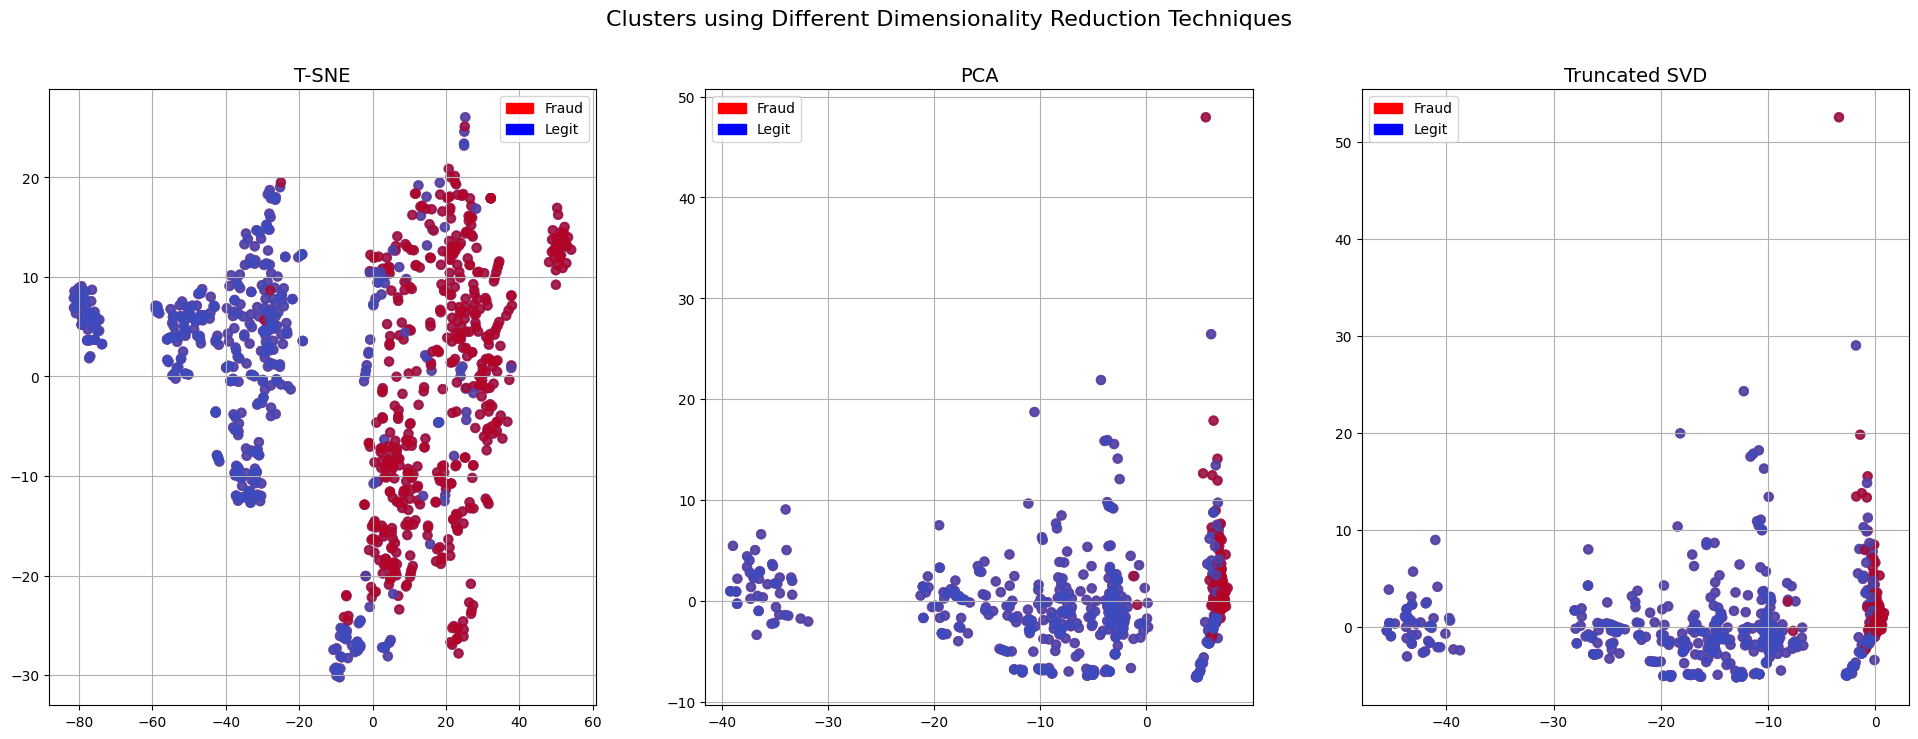

In [30]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))

f.suptitle("Clusters using Different Dimensionality Reduction Techniques", fontsize=16)

red_patch = mpatches.Patch(color="red", label="Fraud")
blue_patch = mpatches.Patch(color="blue", label="Legit")

ax1.scatter(X_reduced_tsne[:, 0], X_reduced_tsne[:, 1], c=(y==1), cmap="coolwarm", label="Fraud", alpha=0.7, linewidths=1.5)
ax1.scatter(X_reduced_tsne[:, 0], X_reduced_tsne[:, 1], c=(y==0), cmap="coolwarm", label="Legit", alpha=0.7, linewidths=1.5)
ax1.set_title("T-SNE", fontsize=14)
ax1.grid(True)
ax1.legend(handles=[red_patch, blue_patch])

ax2.scatter(X_reduced_pca[:, 0], X_reduced_pca[:, 1], c=(y==1), cmap="coolwarm", label="Fraud", alpha=0.7, linewidths=1.5)
ax2.scatter(X_reduced_pca[:, 0], X_reduced_pca[:, 1], c=(y==0), cmap="coolwarm", label="Legit", alpha=0.7, linewidths=1.5)
ax2.set_title("PCA", fontsize=14)
ax2.grid(True)
ax2.legend(handles=[red_patch, blue_patch])

ax3.scatter(X_reduced_svd[:, 0], X_reduced_svd[:, 1], c=(y==1), cmap="coolwarm", label="Fraud", alpha=0.7, linewidths=1.5)
ax3.scatter(X_reduced_svd[:, 0], X_reduced_svd[:, 1], c=(y==0), cmap="coolwarm", label="Legit", alpha=0.7, linewidths=1.5)
ax3.set_title("Truncated SVD", fontsize=14)
ax3.grid(True)
ax3.legend(handles=[red_patch, blue_patch])

In [31]:
X = normal_distributed_df.drop("Class", axis=1)
y = normal_distributed_df["Class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = X_train.values, X_test.values, y_train.values, y_test.values

In [32]:
classifiers= { 
    "XGBoost": XGBClassifier(),
    "Logistic Regression": LogisticRegression(),
    "KNeighborsClassifier": KNeighborsClassifier(),
    "Support Vector Classifier": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
}


In [33]:
for key, classifier in classifiers.items():
    t0 = time.time()
    classifier.fit(X_train, y_train)
    training_score = cross_val_score(classifier, X_train, y_train, cv=5)
    t1 = time.time()
    print(f"{key} training took {t1 - t0:.2f} seconds")
    print(f"Classifiers: {classifier.__class__.__name__}, has a training score of {round(training_score.mean(), 2)*100:.2f}%\n")

XGBoost training took 0.17 seconds
Classifiers: XGBClassifier, has a training score of 100.00%

Logistic Regression training took 0.03 seconds
Classifiers: LogisticRegression, has a training score of 98.00%

KNeighborsClassifier training took 0.02 seconds
Classifiers: KNeighborsClassifier, has a training score of 94.00%

Support Vector Classifier training took 0.02 seconds
Classifiers: SVC, has a training score of 95.00%

Decision Tree training took 0.01 seconds
Classifiers: DecisionTreeClassifier, has a training score of 100.00%

Random Forest training took 0.61 seconds
Classifiers: RandomForestClassifier, has a training score of 100.00%



In [34]:
param_grid = {
    "LogisticRegression": {
        "estimator": LogisticRegression(max_iter=1000),
        "params": {
            "penalty": ["l1", "l2"],
            "C": [0.01, 0.1, 1, 10, 100, 1000],
            "solver": ["liblinear"]
        }
    },
    "KNeighborsClassifier": {
        "estimator": KNeighborsClassifier(),
        "params": {
            "n_neighbors": list(range(2,7)),
            "algorithm": ["auto", "ball_tree", "kd_tree", "brute"]
        }
    },
    "Support Vector Classifier": {
        "estimator": SVC(),
        "params": {
            "C": [0.1, 0.5, 0.9, 1],
            "kernel": ["linear", "rbf", "poly", "sigmoid"]
        }
    },
    "Decision Tree": {
        "estimator": DecisionTreeClassifier(),
        "params": {
            "criterion": ["gini", "entropy"],
            "max_depth": list(range(2, 4)),
            "min_samples_leaf": list(range(2, 4)),
        }
    },
    "RandomForestClassifier": {
        "estimator": RandomForestClassifier(),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [5, 10, None],
            "min_samples_leaf": list(range(2, 4)),
        }
    },
    "XGBoost": {
        "estimator": XGBClassifier(use_label_encoder=False, eval_metric="logloss"),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.05, 0.1, 0.2],
            "subsample": [0.8, 1]
        }
    }
}

best_estimators = {}

for classifier, config in param_grid.items():
    print(f"Running GridSearchCV for {classifier}...")
    grid_search = GridSearchCV(estimator=config["estimator"],
                               param_grid=config["params"],
                               scoring="average_precision",
                               cv=5, 
                               n_jobs=-1, 
                               verbose=1)
    grid_search.fit(X_train, y_train)
    best_estimators[classifier] = grid_search.best_estimator_
    print(f"Best parameters for {classifier}: {grid_search.best_params_}\n")
    print(f"Best score for {classifier}: {grid_search.best_score_:.4f}\n")

Running GridSearchCV for LogisticRegression...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters for LogisticRegression: {'C': 1000, 'penalty': 'l2', 'solver': 'liblinear'}

Best score for LogisticRegression: 0.9997

Running GridSearchCV for KNeighborsClassifier...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters for KNeighborsClassifier: {'algorithm': 'auto', 'n_neighbors': 6}

Best score for KNeighborsClassifier: 0.9692

Running GridSearchCV for Support Vector Classifier...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters for Support Vector Classifier: {'C': 0.9, 'kernel': 'linear'}

Best score for Support Vector Classifier: 0.9997

Running GridSearchCV for Decision Tree...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters for Decision Tree: {'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 2}

Best score for Decision Tree: 0.9984

Running GridSearchCV for RandomFores

In [35]:
for name, model in best_estimators.items():
    score = cross_val_score(model, X_train, y_train, cv=5,
                            scoring="average_precision", n_jobs=-1)
    print(f"{name} Cross Validation AUPRC: {round(score.mean() * 100, 2)}%")

LogisticRegression Cross Validation AUPRC: 99.97%
KNeighborsClassifier Cross Validation AUPRC: 96.92%
Support Vector Classifier Cross Validation AUPRC: 99.97%
Decision Tree Cross Validation AUPRC: 99.84%
RandomForestClassifier Cross Validation AUPRC: 99.97%
XGBoost Cross Validation AUPRC: 100.0%


In [36]:
strat_shuff_split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

X_nearmiss, y_nearmiss = NearMiss().fit_resample(X_train, y_train)

print(f"Nearmiss Label Distribution: {Counter(y_nearmiss)}")

results= {name: {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "auc": [],
    "auprc": []
}
    for name in best_estimators}

for name, model in best_estimators.items():
    print(f"Evaluating {name} with NearMiss undersampling")
    
    for train_Idx, text_Idx in strat_shuff_split.split(X_train, y_train):
        X_fold_train, X_fold_val = X_train[train_Idx], X_train[text_Idx]
        y_fold_train, y_fold_val = y_train[train_Idx], y_train[text_Idx]
        
        pipeline = imbalanced_make_pipeline(
            NearMiss(sampling_strategy="majority"),
            model
        )
        
        pipeline.fit(X_fold_train, y_fold_train)
        y_pred = pipeline.predict(X_fold_val)
        if hasattr(pipeline, "predict_proba"):
            y_prob = pipeline.predict_proba(X_fold_val)[:, 1]
            results[name]["auprc"].append(average_precision_score(y_fold_val, y_prob))
            results[name]["auc"].append(roc_auc_score(y_fold_val, y_prob))
        else:
            results[name]["auprc"].append(None)
            results[name]["auc"].append(roc_auc_score(y_fold_val, y_pred))
        
        results[name]["accuracy"].append(pipeline.score(X_fold_val, y_fold_val))
        results[name]["precision"].append(precision_score(y_fold_val, y_pred, zero_division=0))
        results[name]["recall"].append(recall_score(y_fold_val, y_pred))
        results[name]["f1"].append(f1_score(y_fold_val, y_pred))
        
for name, metrics in results.items():
    print(f"\n{"="*50}")
    print(f"{name}")
    for metric, values in metrics.items():
        valid = [v for v in values if v is not None]
        if valid:
            print(f"  {metric:<12} {round(np.mean(valid) * 100, 2)}%")

Nearmiss Label Distribution: Counter({np.int64(0): 337, np.int64(1): 337})
Evaluating LogisticRegression with NearMiss undersampling
Evaluating KNeighborsClassifier with NearMiss undersampling
Evaluating Support Vector Classifier with NearMiss undersampling
Evaluating Decision Tree with NearMiss undersampling
Evaluating RandomForestClassifier with NearMiss undersampling
Evaluating XGBoost with NearMiss undersampling

LogisticRegression
  accuracy     98.91%
  precision    99.13%
  recall       98.53%
  f1           98.82%
  auc          99.94%
  auprc        99.94%

KNeighborsClassifier
  accuracy     91.43%
  precision    96.74%
  recall       84.41%
  f1           90.0%
  auc          96.27%
  auprc        95.52%

Support Vector Classifier
  accuracy     98.23%
  precision    97.74%
  recall       98.53%
  f1           98.11%
  auc          98.25%

Decision Tree
  accuracy     99.59%
  precision    100.0%
  recall       99.12%
  f1           99.55%
  auc          99.56%
  auprc      

In [37]:
def plot_learning_curves(estimators, X, y, cv=5, n_jobs=-1,
                         train_sizes=np.linspace(0.1, 1.0, 5),
                         scoring="average_precision"):
    
    n_models = len(estimators)
    n_cols   = 2
    n_rows   = (n_models + 1) // 2

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(20, 6 * n_rows),
                             sharey=True)
    axes = axes.flatten()

    for idx, (name, model) in enumerate(estimators.items()):
        ax = axes[idx]

        train_sizes_abs, train_scores, test_scores = learning_curve(
            model, X, y,
            cv=cv,
            n_jobs=n_jobs,
            train_sizes=train_sizes,
            scoring=scoring
        )

        train_mean = np.mean(train_scores, axis=1)
        train_std  = np.std(train_scores,  axis=1)
        test_mean  = np.mean(test_scores,  axis=1)
        test_std   = np.std(test_scores,   axis=1)

        # Confidence bands
        ax.fill_between(train_sizes_abs,
                        train_mean - train_std,
                        train_mean + train_std,
                        alpha=0.1, color="#ff9124")
        ax.fill_between(train_sizes_abs,
                        test_mean - test_std,
                        test_mean + test_std,
                        alpha=0.1, color="#2492ff")

        # Score lines
        ax.plot(train_sizes_abs, train_mean, "o-",
                color="#ff9124", label="Training score")
        ax.plot(train_sizes_abs, test_mean,  "o-",
                color="#2492ff", label="Cross-validation score")

        ax.set_title(f"{name} Learning Curve", fontsize=14)
        ax.set_xlabel("Training size (m)")
        ax.set_ylabel(scoring)
        ax.grid(True)
        ax.legend(loc="best")

    # Hide any unused subplots if odd number of models
    for idx in range(len(estimators), len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.show()

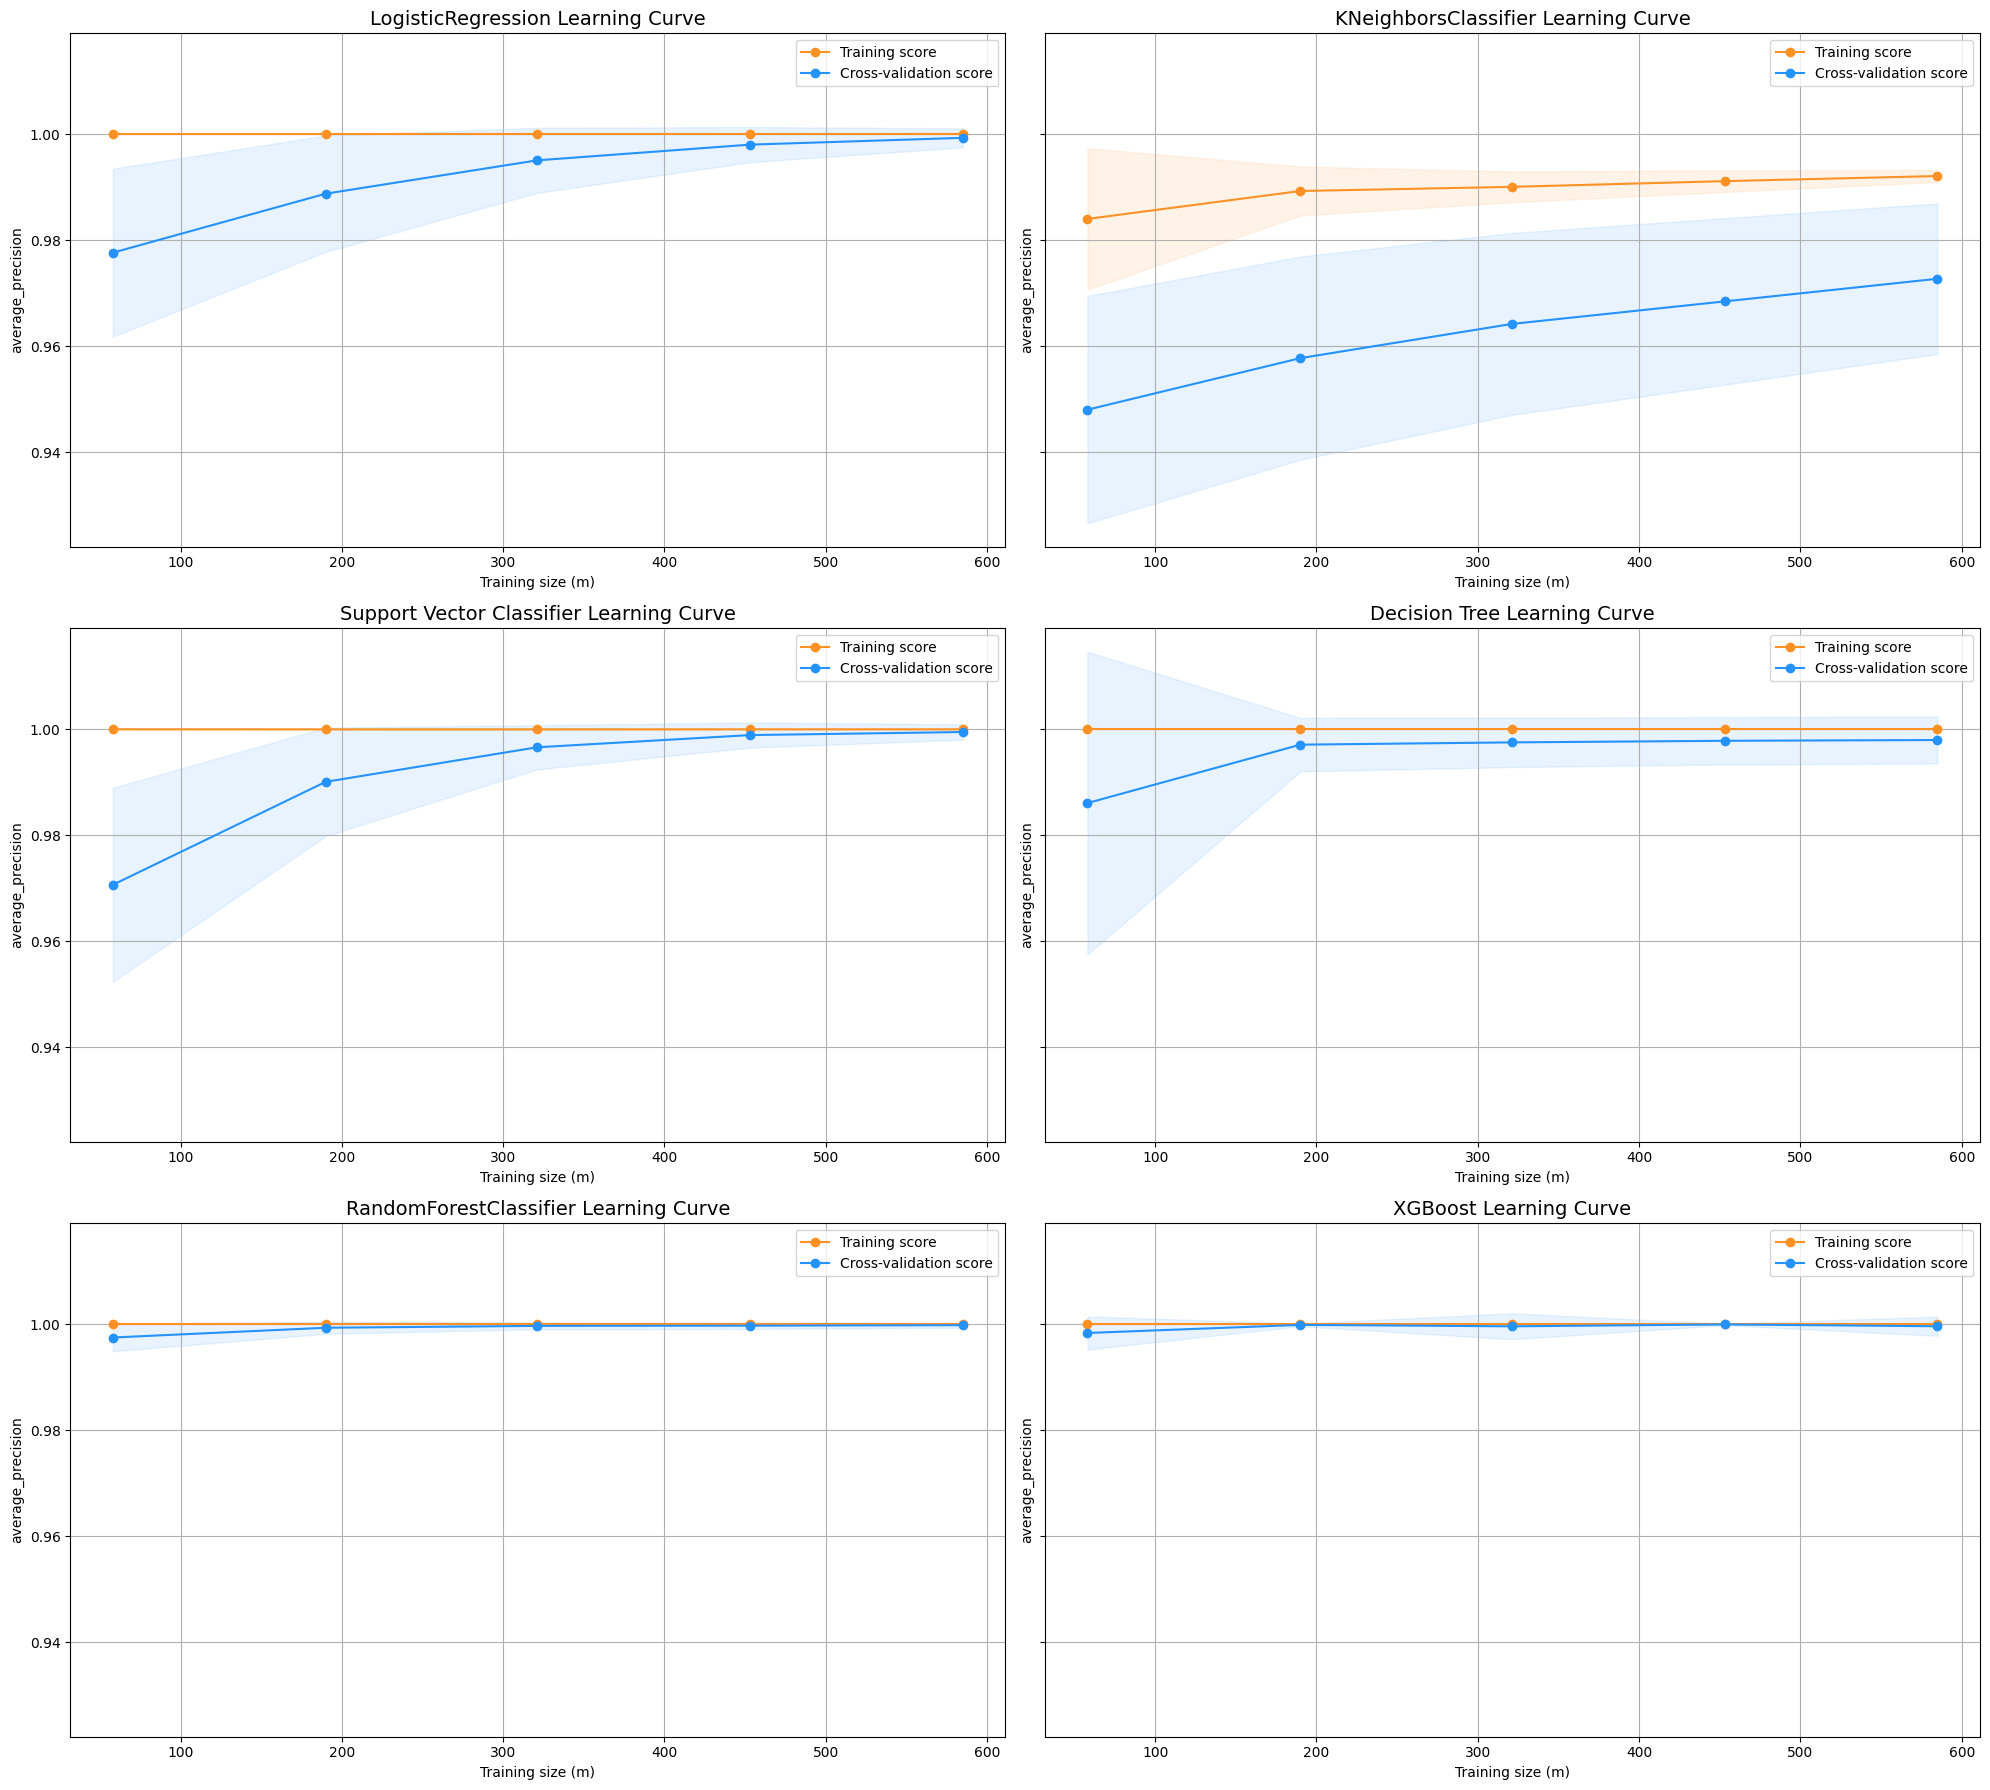

In [38]:
cv = ShuffleSplit(n_splits=100, test_size=0.2, random_state=42)

plot_learning_curves(
    best_estimators,
    X_train, y_train,
    cv=cv,
    n_jobs=-1,
    scoring="average_precision"
)

In [39]:
cv_predictions={}

for name, model in best_estimators.items():
    if hasattr(model, "decision_function"):
       pred = cross_val_predict(model, X_train, y_train, cv=5, method="decision_function")
    else:
       pred = cross_val_predict(model, X_train, y_train, cv=5, method="predict_proba")[:, 1]
       
    cv_predictions[name] = pred
    print(f"{name} ROC-AUC: {roc_auc_score(y_train, pred):.4f}")

LogisticRegression ROC-AUC: 0.9997
KNeighborsClassifier ROC-AUC: 0.9745
Support Vector Classifier ROC-AUC: 0.9997
Decision Tree ROC-AUC: 0.9985
RandomForestClassifier ROC-AUC: 0.9996
XGBoost ROC-AUC: 0.9999


In [40]:
colors = [
    "#2b92fa", "#ff9124", "#00b09b",
    "#ff4b4b", "#9b59b6", "#2ecc71", "#e74c3c"
]

def plot_roc_curves(cv_predictions, y_true):
    plt.figure(figsize=(16,8))
    plt.title("ROC Curve - All classifiers", fontsize=18)
    
    for (name,pred), color in zip(cv_predictions.items(), colors):
        fpr, tpr, _ = roc_curve(y_true, pred)
        auc_score = roc_auc_score(y_true, pred)
        plt.plot(fpr, tpr, color=color, label=f"{name} (AUC = {auc_score:.4f})")
    
    plt.plot([0, 1], [0, 1], "k--", label="Random Chance")
    plt.annotate("Minimum ROC Score of 50%\n(random classifier)", xy=(0.5, 0.5), xytext=(0.6, 0.4),
                 arrowprops=dict(facecolor="#4B4B4B", shrink=0.05))
    
    plt.axis([-0.01, 1, 0, 1])
    plt.xlabel("False Positive Rate", fontsize = 16)
    plt.ylabel("True Positive Rate", fontsize = 16)
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

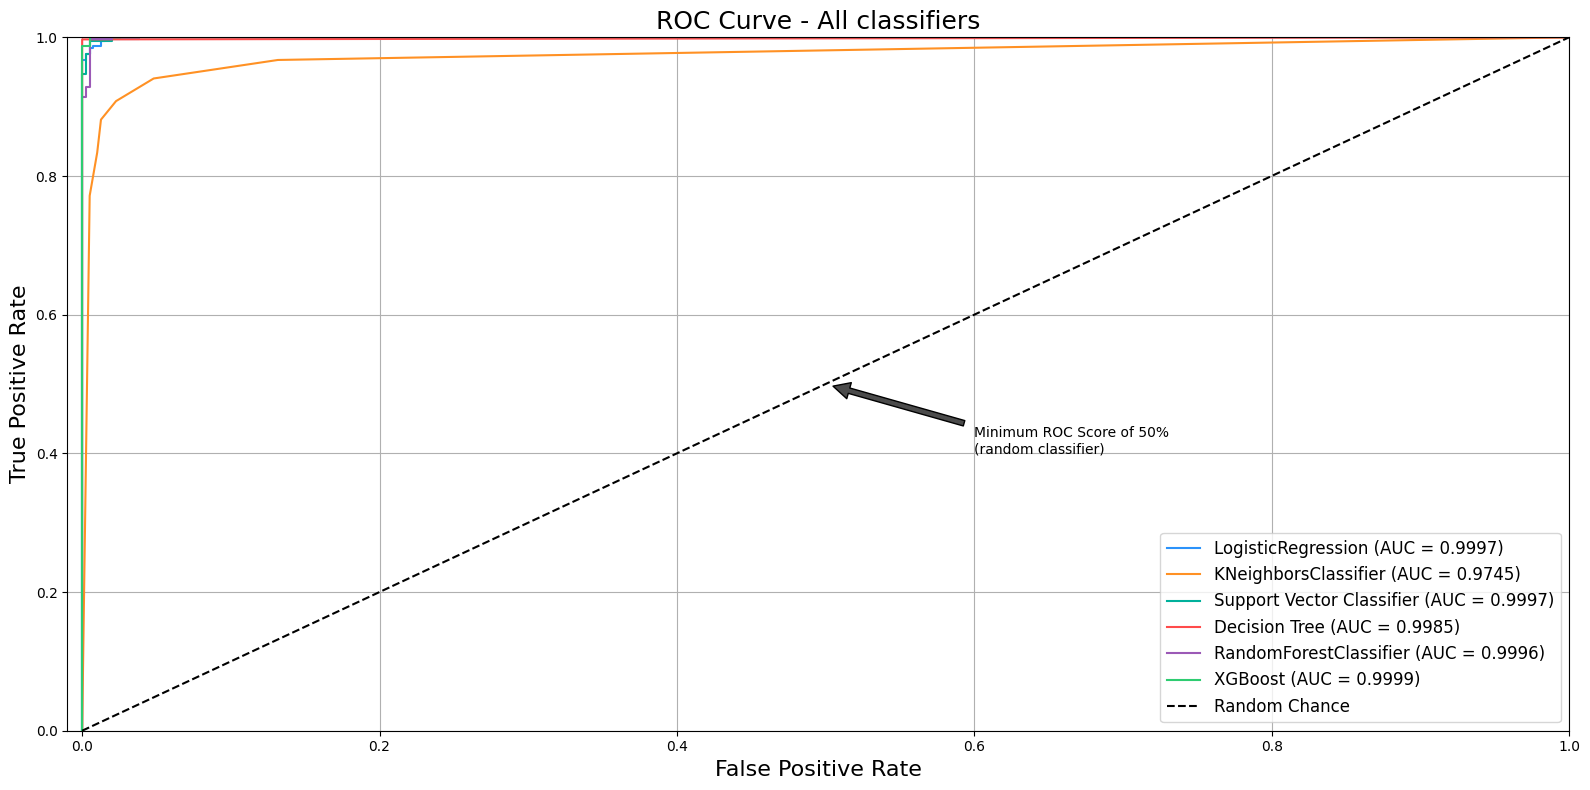

In [41]:
plot_roc_curves(cv_predictions, y_train)

In [42]:
for name,model in best_estimators.items():
    y_pred_train = model.predict(X_train)
    
    print(f"="*50)
    print(f"   {name}")
    print(f"="*50)
    
    print(f"Overfitting check (train set): \n")
    print(f" Recall: {recall_score(y_train, y_pred_train):.4f}")
    print(f" Precision: {precision_score(y_train, y_pred_train):.4f}")
    print(f" F1-Score: {f1_score(y_train, y_pred_train):.4f}")
    print(f" Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
    
    print(f"\n Cross-val NearMiss Undersampling (Expected)\n")
    print(f" Recall: {np.mean(results[name]["recall"]):.4f}")
    print(f" Precision: {np.mean(results[name]["precision"]):.4f}")
    print(f" F1-Score: {np.mean(results[name]["f1"]):.4f}")
    print(f" Accuracy: {np.mean(results[name]["accuracy"]):.4f}")

   LogisticRegression
Overfitting check (train set): 

 Recall: 1.0000
 Precision: 0.9941
 F1-Score: 0.9970
 Accuracy: 0.9973

 Cross-val NearMiss Undersampling (Expected)

 Recall: 0.9853
 Precision: 0.9913
 F1-Score: 0.9882
 Accuracy: 0.9891
   KNeighborsClassifier
Overfitting check (train set): 

 Recall: 0.8961
 Precision: 0.9742
 F1-Score: 0.9335
 Accuracy: 0.9413

 Cross-val NearMiss Undersampling (Expected)

 Recall: 0.8441
 Precision: 0.9674
 F1-Score: 0.9000
 Accuracy: 0.9143
   Support Vector Classifier
Overfitting check (train set): 

 Recall: 0.9941
 Precision: 0.9853
 F1-Score: 0.9897
 Accuracy: 0.9904

 Cross-val NearMiss Undersampling (Expected)

 Recall: 0.9853
 Precision: 0.9774
 F1-Score: 0.9811
 Accuracy: 0.9823
   Decision Tree
Overfitting check (train set): 

 Recall: 0.9970
 Precision: 1.0000
 F1-Score: 0.9985
 Accuracy: 0.9986

 Cross-val NearMiss Undersampling (Expected)

 Recall: 0.9912
 Precision: 1.0000
 F1-Score: 0.9955
 Accuracy: 0.9959
   RandomForestClass

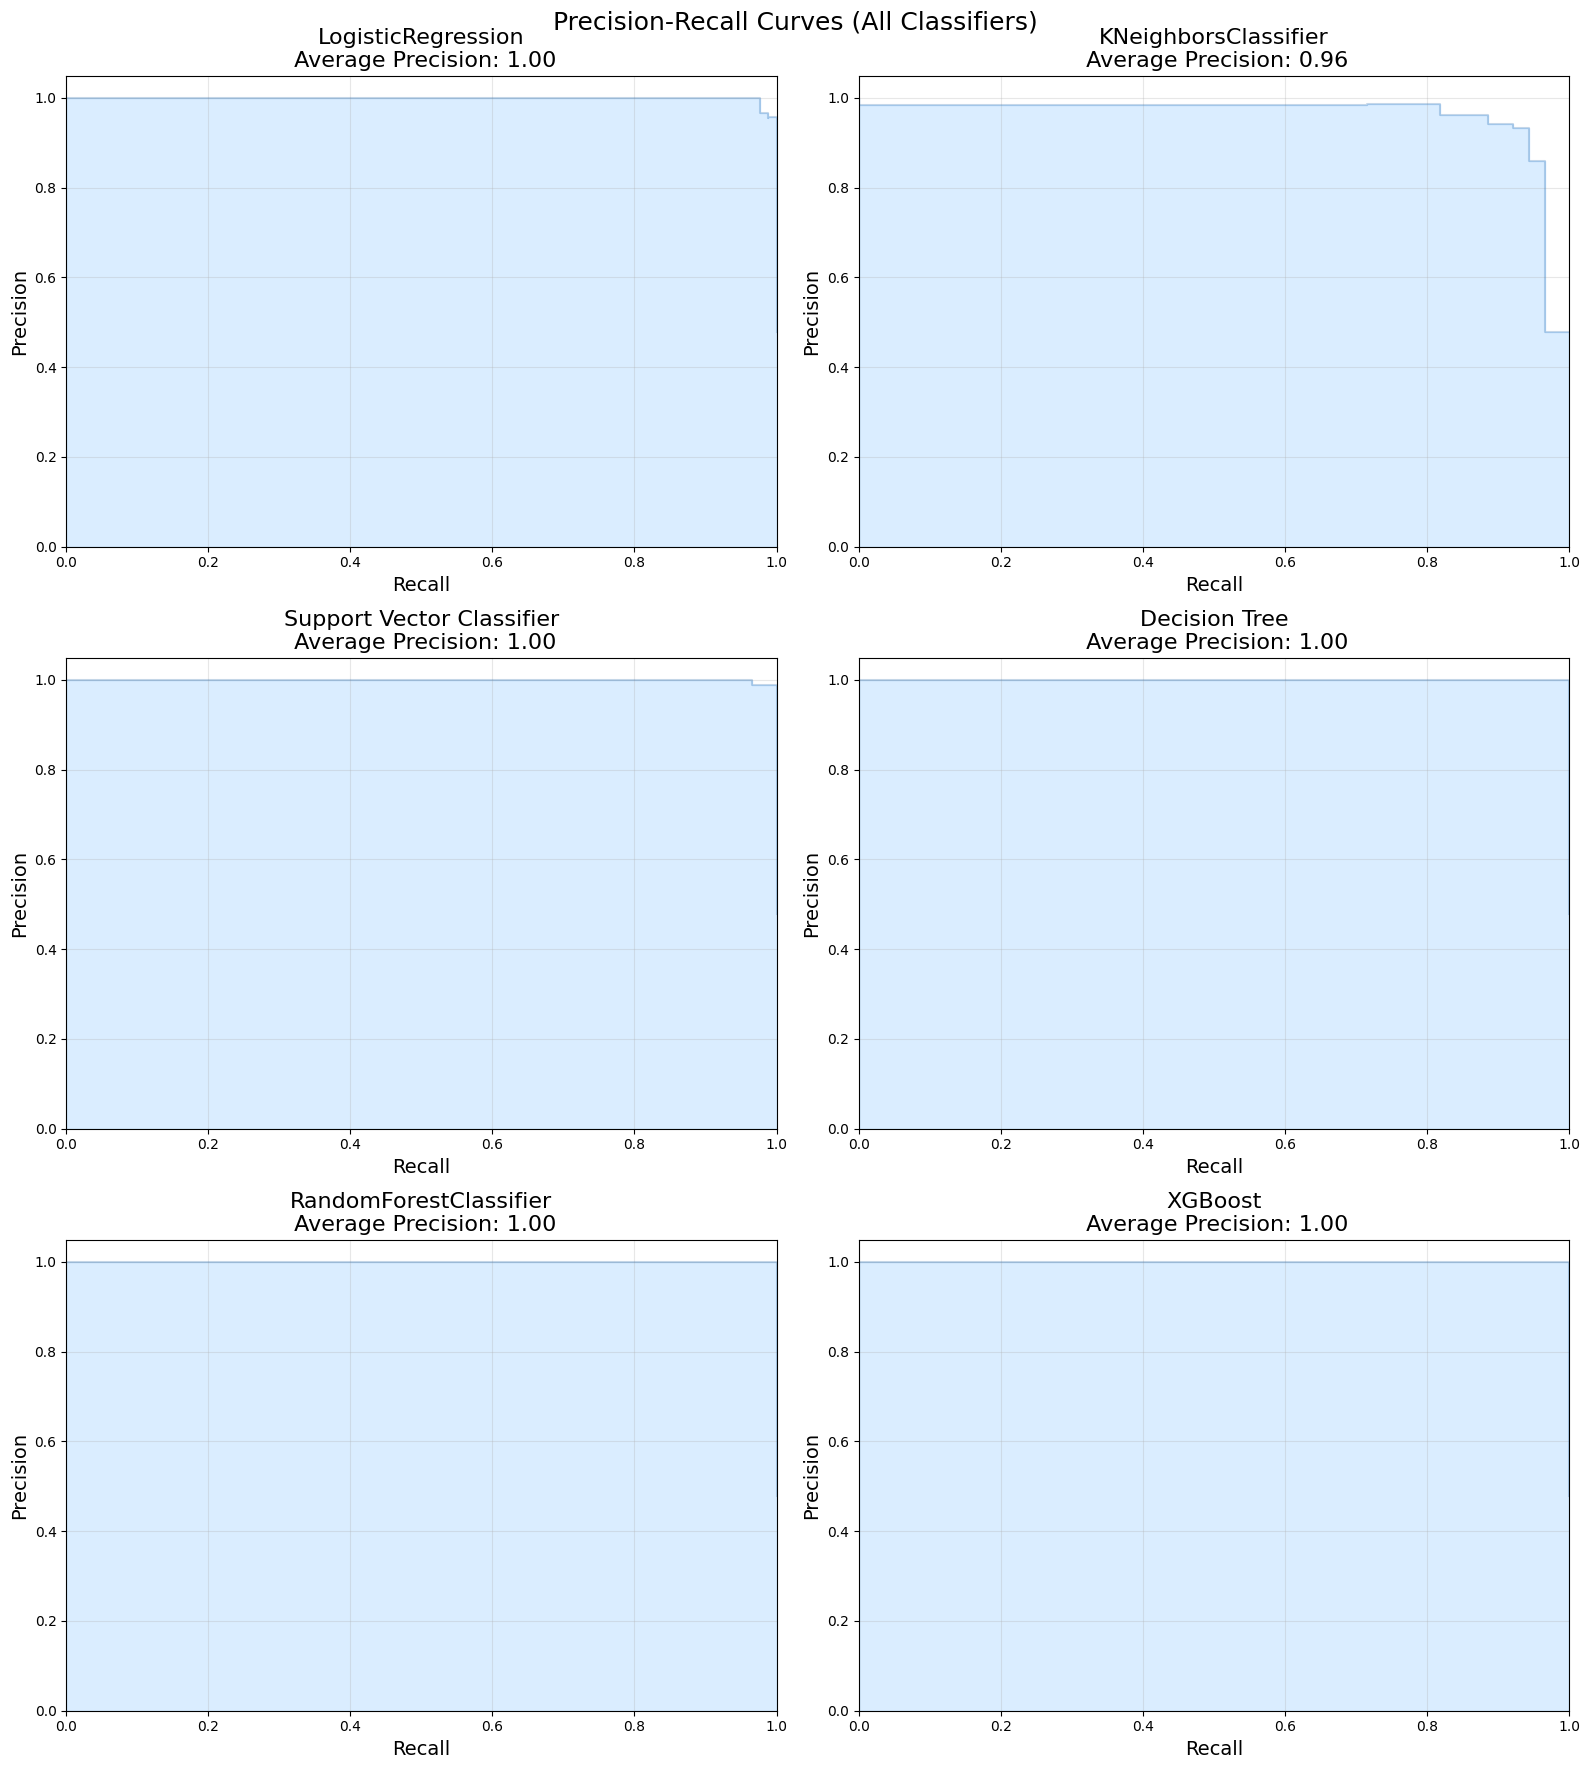

In [43]:
def plot_precision_recall(estimator, X_test, y_test):
    n_model = len(estimator)
    n_col = 2
    n_row = (n_model + 1) // n_col
    
    fig, axes = plt.subplots(n_row, n_col, figsize=(16, 6 * n_row))
    axes = axes.flatten()
    
    for idx, (name, model) in enumerate(estimator.items()):
        ax = axes[idx]
        
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test)[:, 1]
        elif hasattr(model, "decision_function"):
            y_score = model.decision_function(X_test)
        else:
            y_score = model.predict(X_test)
            
        average_precision = average_precision_score(y_test, y_score)
        precision, recall, _ = precision_recall_curve(y_test, y_score)
        
        ax.step(recall, precision, color = "#004a93", alpha=0.2, where="post")
        ax.fill_between(recall, precision, step="post", alpha=0.2, color="#48a6ff")
        
        ax.set_xlabel("Recall", fontsize=14)
        ax.set_ylabel("Precision", fontsize=14)
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_title(f"{name}\n Average Precision: {average_precision:.2f}", fontsize=16)
        ax.grid(True, alpha=0.3)
        
        for idx in range(len(estimator), len(axes)):
            axes[idx].set_visible(False)
            
        plt.suptitle("Precision-Recall Curves (All Classifiers)", fontsize=18)
    plt.tight_layout()
    plt.show()
    
plot_precision_recall(best_estimators, X_test, y_test)

In [44]:
def plot_confusion_matrices(estimator, X_test, y_test, cmap="Blues"):
    n_models = len(estimator)
    n_cols = 2
    n_rows = (n_models + 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 6 * n_rows))
    axes = axes.flatten()
    
    for idx, (name, model) in enumerate(estimator.items()):
        ax = axes[idx]
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        
        sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, ax=ax)
        ax.set_xlabel("Predicted Label", fontsize=14)
        ax.set_ylabel("True Label", fontsize=14)
        ax.set_title(f"{name} - Confusion Matrix", fontsize=16)
        
    for idx in range(len(estimator), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle("Confusion Matrices (All Classifiers)", fontsize=18)
    plt.tight_layout()
    plt.show()
    


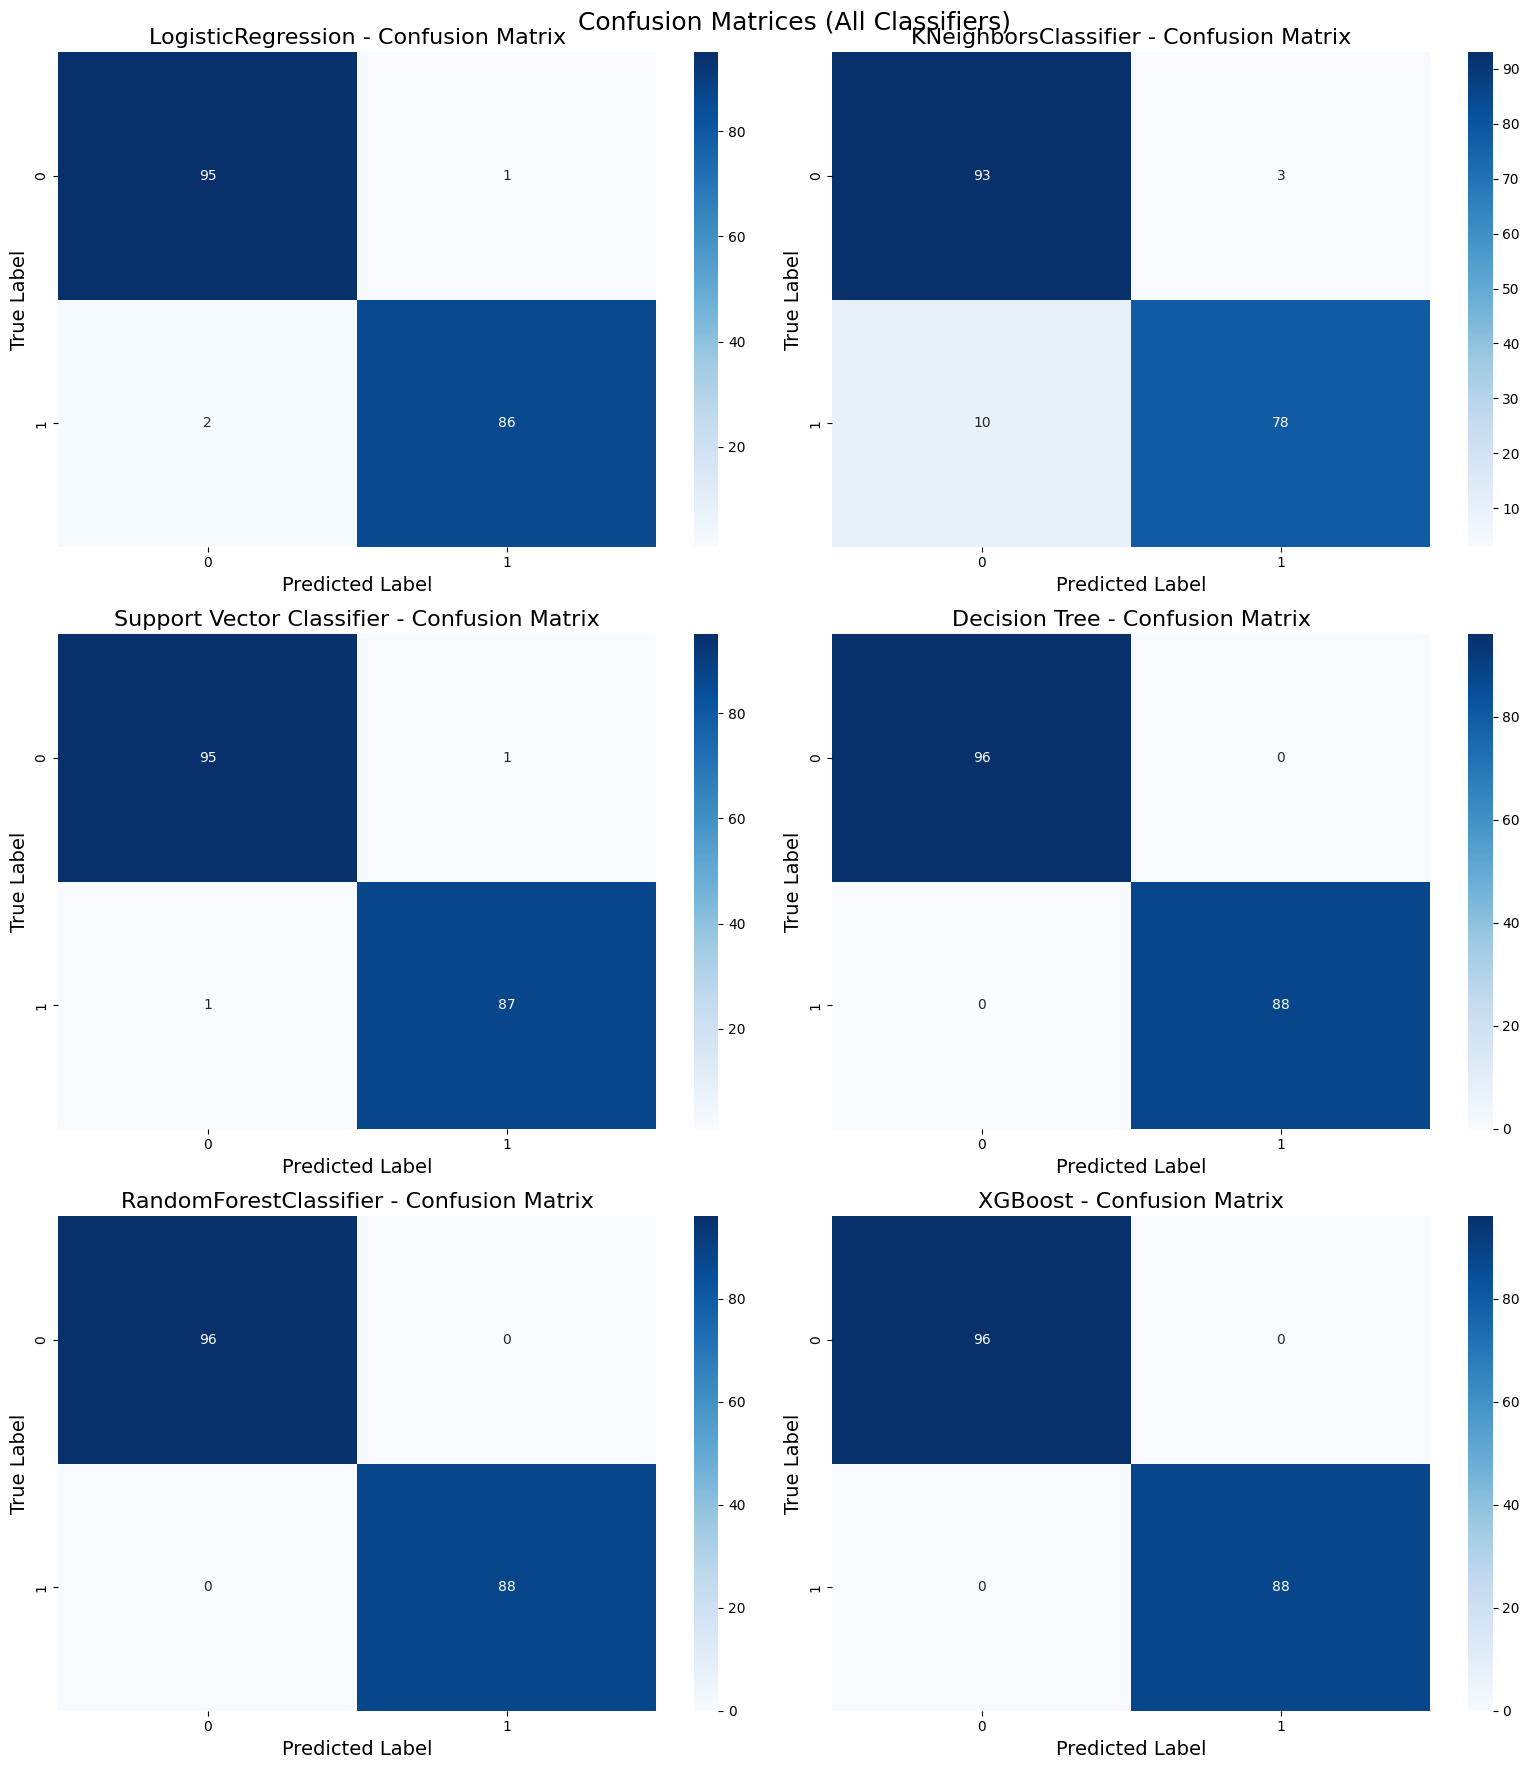

In [45]:
plot_confusion_matrices(best_estimators, X_test, y_test)

In [46]:
for name, model in best_estimators.items():
    y_pred = model.predict(X_test)
    print('=' * 50)
    print(f'  {name}')
    print('=' * 50)
    print(classification_report(y_test, y_pred,
                                target_names=['Legit', 'Fraud'],
                                digits=4))

  LogisticRegression
              precision    recall  f1-score   support

       Legit     0.9794    0.9896    0.9845        96
       Fraud     0.9885    0.9773    0.9829        88

    accuracy                         0.9837       184
   macro avg     0.9839    0.9834    0.9837       184
weighted avg     0.9837    0.9837    0.9837       184

  KNeighborsClassifier
              precision    recall  f1-score   support

       Legit     0.9029    0.9688    0.9347        96
       Fraud     0.9630    0.8864    0.9231        88

    accuracy                         0.9293       184
   macro avg     0.9329    0.9276    0.9289       184
weighted avg     0.9316    0.9293    0.9291       184

  Support Vector Classifier
              precision    recall  f1-score   support

       Legit     0.9896    0.9896    0.9896        96
       Fraud     0.9886    0.9886    0.9886        88

    accuracy                         0.9891       184
   macro avg     0.9891    0.9891    0.9891       184
we

In [47]:
X_full = df_scaled.drop("Class", axis=1)
y_full = df_scaled["Class"]

X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X_full, y_full,
    test_size=0.2,
    stratify=y_full,    # preserves 0.17% fraud rate in both splits
    random_state=42
)

print(f"Test set fraud cases: {y_test_orig.sum()}")       # ~98
print(f"Test set legit cases: {(y_test_orig==0).sum()}")  # ~56,963
print(f"Fraud rate in test:   {y_test_orig.mean():.4f}")  # ~0.0017

for name, model in best_estimators.items():
    y_pred = model.predict(X_test_orig)
    y_prob = (model.predict_proba(X_test_orig)[:, 1]
              if hasattr(model, 'predict_proba')
              else model.decision_function(X_test_orig))

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test_orig, y_pred,
                                target_names=['Legit', 'Fraud'],
                                digits=4))
    print(f"  ROC-AUC: {roc_auc_score(y_test_orig, y_prob):.4f}")
    print(f"  AUPRC:   {average_precision_score(y_test_orig, y_prob):.4f}")

Test set fraud cases: 98
Test set legit cases: 56864
Fraud rate in test:   0.0017

  LogisticRegression
              precision    recall  f1-score   support

       Legit     0.9997    0.1528    0.2651     56864
       Fraud     0.0020    0.9694    0.0039        98

    accuracy                         0.1542     56962
   macro avg     0.5008    0.5611    0.1345     56962
weighted avg     0.9979    0.1542    0.2647     56962

  ROC-AUC: 0.7541
  AUPRC:   0.0189

  KNeighborsClassifier
              precision    recall  f1-score   support

       Legit     0.9999    0.9406    0.9693     56864
       Fraud     0.0262    0.9286    0.0510        98

    accuracy                         0.9406     56962
   macro avg     0.5130    0.9346    0.5102     56962
weighted avg     0.9982    0.9406    0.9677     56962

  ROC-AUC: 0.9768
  AUPRC:   0.0979

  Support Vector Classifier
              precision    recall  f1-score   support

       Legit     0.9996    0.1246    0.2216     56864
       F

# These results show that despite trying to be careful about it, overfitting did happen due to how much data processing was involved, next we will make sure this cannot happen and use more direct methods to make our algorithms correct

In [48]:
df_raw = pd.read_csv("./Data/creditcard.csv")

amount_scaler = RobustScaler()
time_scaler = RobustScaler()

df_raw["scaled_amount"] = amount_scaler.fit_transform(df_raw["Amount"].values.reshape(-1, 1))
df_raw["scaled_time"] = time_scaler.fit_transform(df_raw["Time"].values.reshape(-1, 1))
df_raw.drop(["Amount", "Time"], axis=1, inplace=True)

X_raw = df_raw.drop("Class", axis=1)
y_raw = df_raw["Class"]

In [49]:
df_raw.shape

(284807, 31)

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, stratify=y_raw, random_state=42
)

In [51]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((227845, 30), (227845,), (56962, 30), (56962,))

In [52]:
scale_position_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

In [ ]:
# For SVC, we take a 30K subset of the training data to keep the quadratic complexity manageable.
_, X_svc, _, y_svc = train_test_split(
    X_train, y_train,
    test_size=30_000,
    stratify=y_train,
    random_state=42
)

cv_per_model = {
    "LogisticRegression": StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    "KNeighborsClassifier": StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    "SVC": StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    "DecisionTree": StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    "RandomForest": StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    "XGBoost": StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
}

param_grid = {
    "LogisticRegression": {
        "estimator": LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear"),
        "params": {
            "penalty": ["l1", "l2"],
            "C": [0.1, 1, 10],
        },
        "search": "grid",
    },

    "KNeighborsClassifier": {
        "estimator": KNeighborsClassifier(algorithm="ball_tree"),
        "params": {
            "n_neighbors": [5, 7, 11],
        },
        "search": "grid",
    },
    
    # Changed kernel SVC to linear SVC with calibration for much faster training while keeping probability for AU PRC evaluation
    "SVC": {
        "estimator": CalibratedClassifierCV(
            LinearSVC(class_weight="balanced", max_iter=2000),
            cv=2,
            method="sigmoid"
        ),
        "params": {
            "estimator__C": [0.1, 1, 10],
        },
        "search": "grid",
        "X": X_svc,
        "y": y_svc,
    },

    "DecisionTree": {
        "estimator": DecisionTreeClassifier(criterion="gini", class_weight="balanced"),
        "params": {
            "max_depth": [3, 5, 8],
            "min_samples_leaf": [1, 2, 4],
        },
        "search": "grid",
    },

    "RandomForest": {
        "estimator": RandomForestClassifier(
            n_estimators=120,
            class_weight="balanced_subsample",
            random_state=42
        ),
        "params": {
            "max_depth": [5, 10, 15, None],
            "min_samples_leaf": [1, 2, 4],
            "max_features": ["sqrt", 0.3],
        },
        "search": "random",
        "n_iter": 15,
    },

    "XGBoost": {
        "estimator": XGBClassifier(
            eval_metric="aucpr",
            scale_pos_weight=scale_position_weight,
            n_estimators=500,
            early_stopping_rounds=15,
            random_state=42,
        ),
        "params": {
            "max_depth": [3, 4, 5, 6],
            "learning_rate": [0.03, 0.05, 0.1, 0.15],
            "subsample": [0.7, 0.8, 1.0],
            "min_child_weight": [1, 5, 10],
            "colsample_bytree": [0.7, 0.9, 1.0],
        },
        "search": "random",
        "n_iter": 20,
    },
}

X_xgb_tr, X_xgb_val, y_xgb_tr, y_xgb_val = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=42
)

best_estimators = {}
COMMON = dict(scoring="average_precision", n_jobs=-1, verbose=1, refit=True)

for name, config in param_grid.items():
    print(f"\nRunning search for {name}...")

    X_fit = config.get("X", X_train)
    y_fit = config.get("y", y_train)

    if config["search"] == "grid":
        searcher = GridSearchCV(
            estimator=config["estimator"],
            param_grid=config["params"],
            cv=cv_per_model[name],
            **COMMON,
        )
        searcher.fit(X_fit, y_fit)

    else:
        searcher = RandomizedSearchCV(
            estimator=config["estimator"],
            param_distributions=config["params"],
            n_iter=config["n_iter"],
            cv=cv_per_model[name],
            random_state=42,
            **COMMON,
        )
        # XGBoost early stopping eval_set
        fit_params = (
            {"eval_set": [(X_xgb_val, y_xgb_val)], "verbose": False}
            if name == "XGBoost" else {}
        )
        searcher.fit(X_fit, y_fit, **fit_params)

    best_estimators[name] = {
        "estimator": searcher.best_estimator_,
        "best_params": searcher.best_params_,
        "cv_score": searcher.best_score_,
    }
    print(f"  Best params : {searcher.best_params_}")
    print(f"  CV PR-AUC  : {searcher.best_score_:.4f}")


Running search for LogisticRegression...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
  Best params : {'C': 0.1, 'penalty': 'l2'}
  CV PR-AUC   : 0.7568

Running search for KNeighborsClassifier...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
  Best params : {'n_neighbors': 5}
  CV PR-AUC   : 0.7944

Running search for SVC...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
  Best params : {'estimator__C': 10}
  CV PR-AUC   : 0.5583

Running search for DecisionTree...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
  Best params : {'max_depth': 8, 'min_samples_leaf': 4}
  CV PR-AUC   : 0.5843

Running search for RandomForest...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
  Best params : {'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
  CV PR-AUC   : 0.8380

Running search for XGBoost...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
  Best params : {'subsample': 0.8, 'min_child_weight'

Running search for LogisticRegression...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
  Best params : {'C': 0.1, 'penalty': 'l2'}
  CV PR-AUC   : 0.7568

Running search for KNeighborsClassifier...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
  Best params : {'n_neighbors': 5}
  CV PR-AUC   : 0.7944

Running search for SVC...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
  Best params : {'estimator__C': 10}
  CV PR-AUC   : 0.5583

Running search for DecisionTree...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
  Best params : {'max_depth': 8, 'min_samples_leaf': 4}
  CV PR-AUC   : 0.5843

Running search for RandomForest...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
  Best params : {'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
  CV PR-AUC   : 0.8380

Running search for XGBoost...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
  Best params : {'subsample': 0.8, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.15, 'colsample_bytree': 0.9}
  CV PR-AUC   : 0.8507

  Cross-validating: LogisticRegression
    ROC-AUC: 0.9769
  Cross-validating: KNeighborsClassifier
    ROC-AUC: 0.9123
  Cross-validating: SVC
    ROC-AUC: 0.8933
  Cross-validating: DecisionTree
    ROC-AUC: 0.9003
  Cross-validating: RandomForest
    ROC-AUC: 0.9488
  Cross-validating: XGBoost
    ROC-AUC: 0.9810


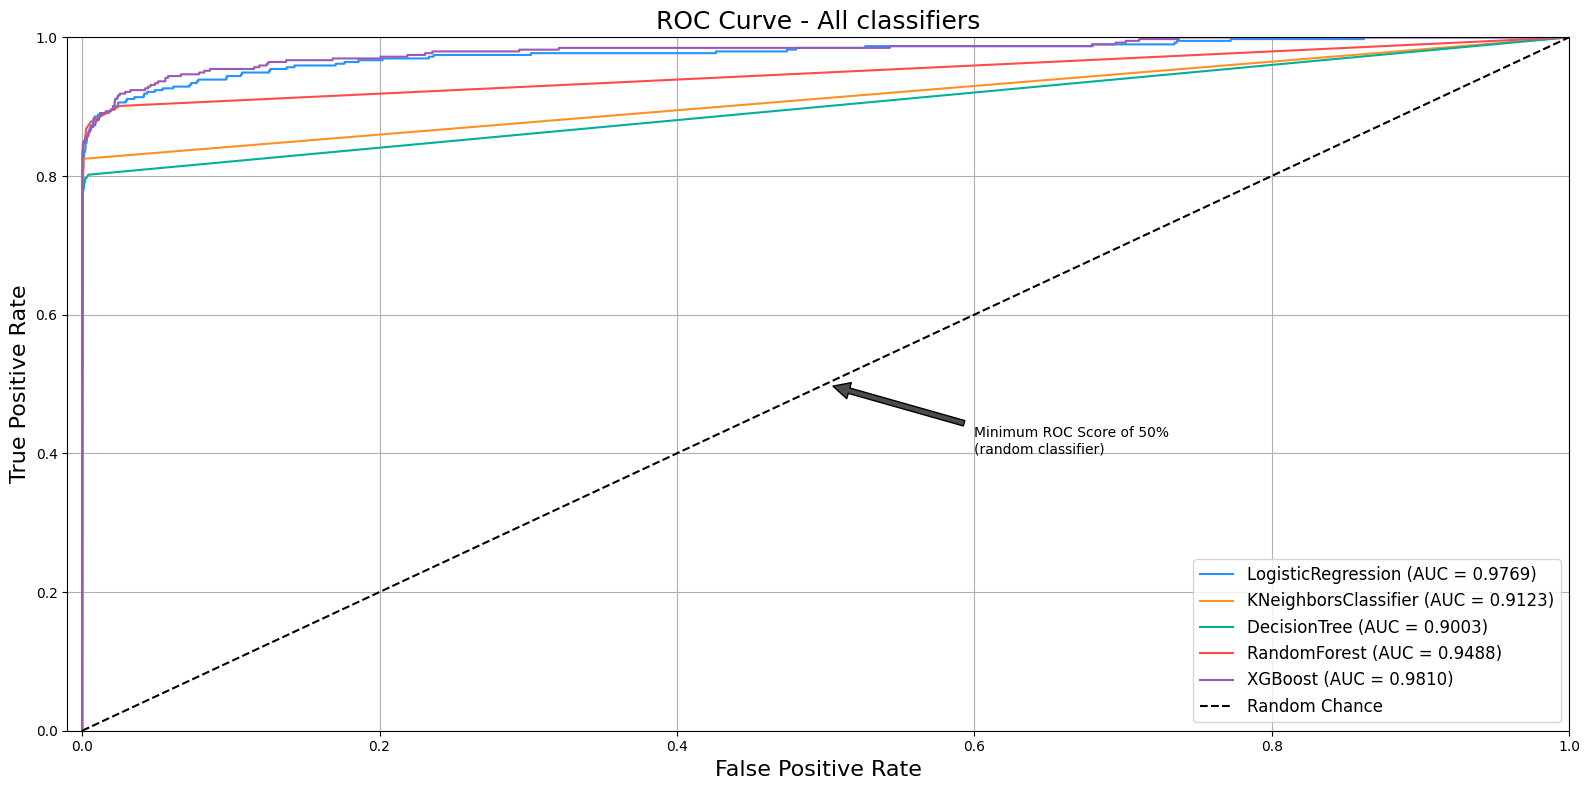

In [58]:
cv_predictions = {}

for name, config in best_estimators.items():
    model = config["estimator"]
    print(f"  Cross-validating: {name}")

    X_cv, y_cv = (X_svc, y_svc) if name == "SVC" else (X_train, y_train)

    if name == "XGBoost":
        model = clone(model)
        model.set_params(early_stopping_rounds=None)

    if hasattr(model, 'predict_proba'):
        prob = cross_val_predict(
            model, X_cv, y_cv, cv=2,
            method='predict_proba', n_jobs=-1
        )[:, 1]
    else:
        prob = cross_val_predict(
            model, X_cv, y_cv, cv=2,
            method='decision_function', n_jobs=-1
        )

    cv_predictions[name] = prob
    y_cv_true = y_svc if name == "SVC" else y_train
    print(f"    ROC-AUC: {roc_auc_score(y_cv_true, prob):.4f}")

cv_predictions_full = {k: v for k, v in cv_predictions.items() if k != "SVC"}
plot_roc_curves(cv_predictions_full, y_train)

In [60]:
# Fit, Predict & Collect All Metrics
colors = ['#2492ff', '#ff9124', '#00b09b', '#ff4b4b', '#9b59b6', '#2ecc71']
all_metrics = []
model_probs  = {}
model_preds  = {}

for name, config in best_estimators.items():
    model  = config["estimator"]
    X_fit, y_fit = (X_svc, y_svc) if name == "SVC" else (X_train, y_train)

    if name == "XGBoost":
        # clone to avoid mutating the stored estimator
        model = clone(model)
        model.fit(
            X_xgb_tr, y_xgb_tr,
            eval_set=[(X_xgb_val, y_xgb_val)],
            verbose=False
        )
    else:
        model.fit(X_fit, y_fit)

    y_pred = model.predict(X_test)
    y_prob = (model.predict_proba(X_test)[:, 1]
              if hasattr(model, 'predict_proba')
              else model.decision_function(X_test))

    model_probs[name] = y_prob
    model_preds[name] = y_pred

    all_metrics.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_prob),
        'AUPRC':     average_precision_score(y_test, y_prob),
    })

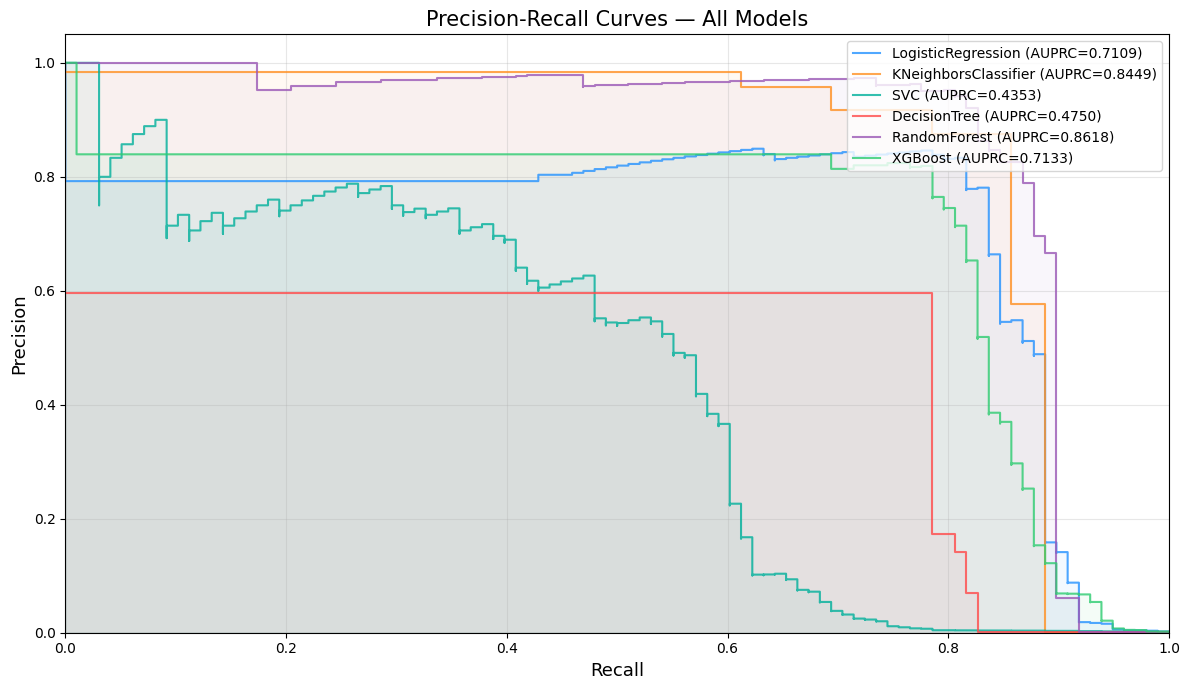

In [61]:
# ── 4. Precision-Recall Curves ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

for (name, y_prob), color in zip(model_probs.items(), colors):
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
    auprc = average_precision_score(y_test, y_prob)
    ax.step(recall_vals, precision_vals, color=color, alpha=0.8, where='post',
            label=f'{name} (AUPRC={auprc:.4f})')
    ax.fill_between(recall_vals, precision_vals, step='post', alpha=0.05, color=color)

ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_ylim([0.0, 1.05])
ax.set_xlim([0.0, 1.0])
ax.set_title('Precision-Recall Curves — All Models', fontsize=15)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

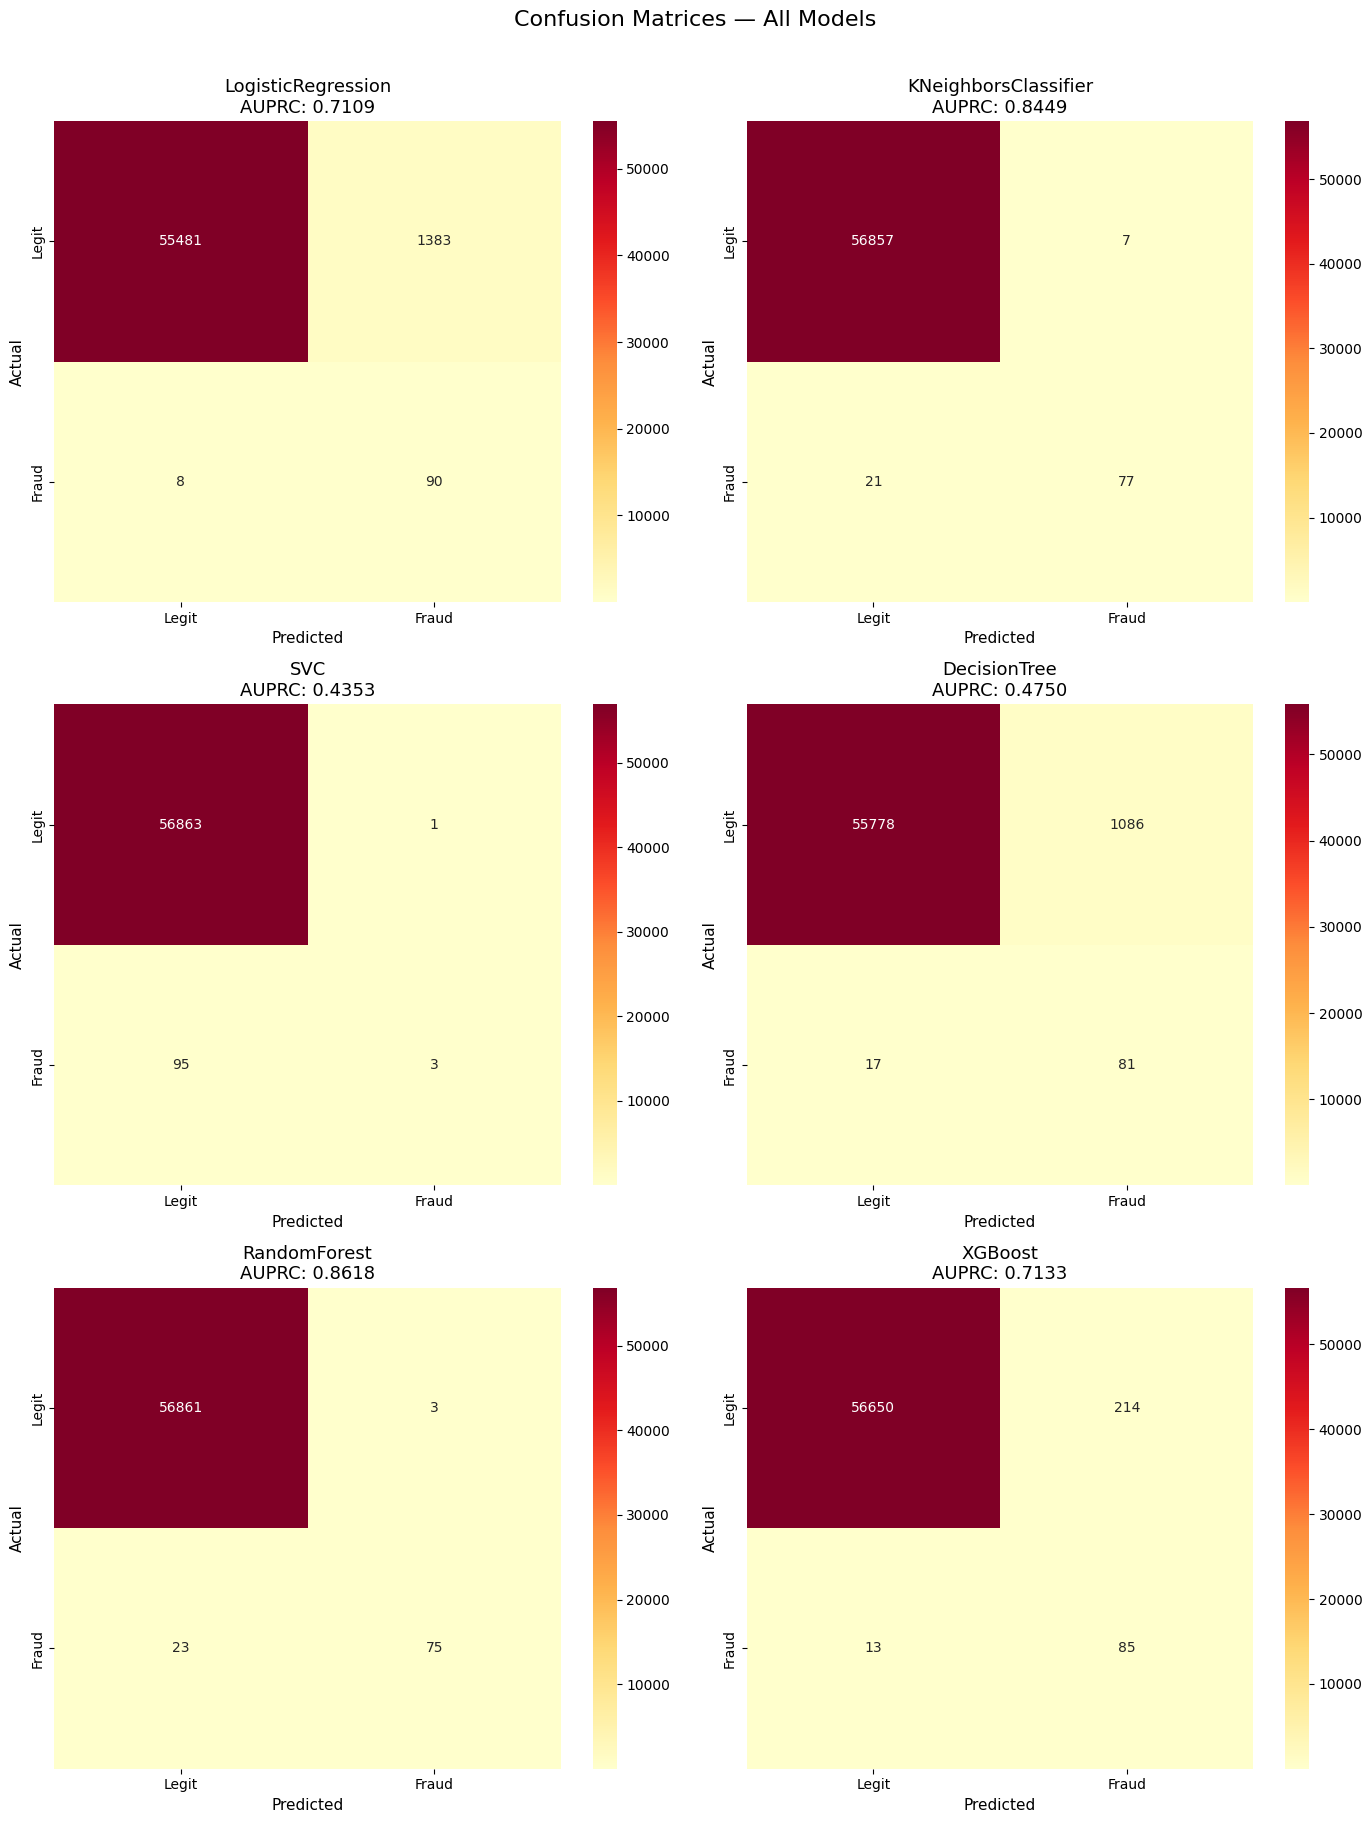

In [62]:
# ── 5. Confusion Matrices ─────────────────────────────────────────────────────
n_models = len(best_estimators)
n_cols   = 2
n_rows   = (n_models + 1) // 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 6 * n_rows))
axes = axes.flatten()

for idx, (name, y_pred) in enumerate(model_preds.items()):
    ax = axes[idx]
    cf = confusion_matrix(y_test, y_pred)
    sns.heatmap(cf, ax=ax, annot=True, fmt='d', cmap='YlOrRd',
                xticklabels=['Legit', 'Fraud'],
                yticklabels=['Legit', 'Fraud'])
    auprc = average_precision_score(y_test, model_probs[name])
    ax.set_title(f'{name}\nAUPRC: {auprc:.4f}', fontsize=13)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual',    fontsize=11)

for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Confusion Matrices — All Models', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

In [63]:
# Classification Reports
for name, y_pred in model_preds.items():
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred,
                                target_names=['Legit', 'Fraud'],
                                digits=4))


  LogisticRegression
              precision    recall  f1-score   support

       Legit     0.9999    0.9757    0.9876     56864
       Fraud     0.0611    0.9184    0.1146        98

    accuracy                         0.9756     56962
   macro avg     0.5305    0.9470    0.5511     56962
weighted avg     0.9982    0.9756    0.9861     56962


  KNeighborsClassifier
              precision    recall  f1-score   support

       Legit     0.9996    0.9999    0.9998     56864
       Fraud     0.9167    0.7857    0.8462        98

    accuracy                         0.9995     56962
   macro avg     0.9581    0.8928    0.9230     56962
weighted avg     0.9995    0.9995    0.9995     56962


  SVC
              precision    recall  f1-score   support

       Legit     0.9983    1.0000    0.9992     56864
       Fraud     0.7500    0.0306    0.0588        98

    accuracy                         0.9983     56962
   macro avg     0.8742    0.5153    0.5290     56962
weighted avg     0.99

In [64]:
# Final leaderboard summary sorted by AUPRC
summary_df = (pd.DataFrame(all_metrics)
                .set_index('Model')
                .sort_values('AUPRC', ascending=False)
                .round(4))


In [ ]:

print("\n\n" + "═"*70)
print("  FINAL LEADERBOARD — Sorted by AUPRC (primary metric)")
print("═"*70)
print(summary_df.to_string())
print("\n  Best overall model:", summary_df['AUPRC'].idxmax())
print(f" AUPRC: {summary_df['AUPRC'].max():.4f}")
print(f" ROC-AUC: {summary_df.loc[summary_df['AUPRC'].idxmax(), 'ROC-AUC']:.4f}")
print(f" F1: {summary_df.loc[summary_df['AUPRC'].idxmax(), 'F1']:.4f}")
print(f" Recall: {summary_df.loc[summary_df['AUPRC'].idxmax(), 'Recall']:.4f}")



══════════════════════════════════════════════════════════════════════
  FINAL LEADERBOARD — Sorted by AUPRC (primary metric)
══════════════════════════════════════════════════════════════════════
                      Accuracy  Precision  Recall      F1  ROC-AUC   AUPRC
Model                                                                     
RandomForest            0.9995     0.9615  0.7653  0.8523   0.9578  0.8618
KNeighborsClassifier    0.9995     0.9167  0.7857  0.8462   0.9438  0.8449
XGBoost                 0.9960     0.2843  0.8673  0.4282   0.9714  0.7133
LogisticRegression      0.9756     0.0611  0.9184  0.1146   0.9721  0.7109
DecisionTree            0.9806     0.0694  0.8265  0.1281   0.9075  0.4750
SVC                     0.9983     0.7500  0.0306  0.0588   0.8736  0.4353

  Best overall model: RandomForest
   AUPRC:   0.8618
   ROC-AUC: 0.9578
   F1:      0.8523
   Recall:  0.7653


In [ ]:
spw = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Correct scale_pos_weight: {spw:.1f}")  # ~577

spw_conservative = spw * 0.5

all_metrics = []
model_probs  = {}
model_preds  = {}

for name, config in best_estimators.items():
    model        = clone(config["estimator"])
    X_fit, y_fit = (X_svc, y_svc) if name == "SVC" else (X_train, y_train)

    if name == "XGBoost":
        model.set_params(scale_pos_weight=spw_conservative)
        X_tr_, X_val_, y_tr_, y_val_ = train_test_split(
            X_fit, y_fit, test_size=0.1, stratify=y_fit, random_state=42
        )
        model.fit(X_tr_, y_tr_, eval_set=[(X_val_, y_val_)], verbose=False)

    elif name == "LogisticRegression":
        # less aggressive class weight via manual dict instead of 'balanced'
        model.set_params(
            class_weight={0: 1, 1: 50},
            C=0.1
        )
        model.fit(X_fit, y_fit)

    elif name == "SVC":
        _, X_svc_large, _, y_svc_large = train_test_split(
            X_train, y_train,
            test_size=80_000,
            stratify=y_train,
            random_state=42
        )
        model.fit(X_svc_large, y_svc_large)

    else:
        model.fit(X_fit, y_fit)

    y_pred = model.predict(X_test)
    y_prob = (model.predict_proba(X_test)[:, 1]
              if hasattr(model, 'predict_proba')
              else model.decision_function(X_test))

    model_probs[name] = y_prob
    model_preds[name] = y_pred

    all_metrics.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'AUPRC': average_precision_score(y_test, y_prob),
    })

summary_df = (pd.DataFrame(all_metrics)
                .set_index('Model')
                .sort_values('AUPRC', ascending=False)
                .round(4))

print("\n" + "═"*60)
print("  FINAL LEADERBOARD — Sorted by AUPRC")
print("═"*60)
print(summary_df.to_string())
print(f"\n★  Best model: {summary_df['AUPRC'].idxmax()}")
print(f" AUPRC: {summary_df['AUPRC'].max():.4f}")
print(f" ROC-AUC: {summary_df.loc[summary_df['AUPRC'].idxmax(), 'ROC-AUC']:.4f}")
print(f" Recall: {summary_df.loc[summary_df['AUPRC'].idxmax(), 'Recall']:.4f}")

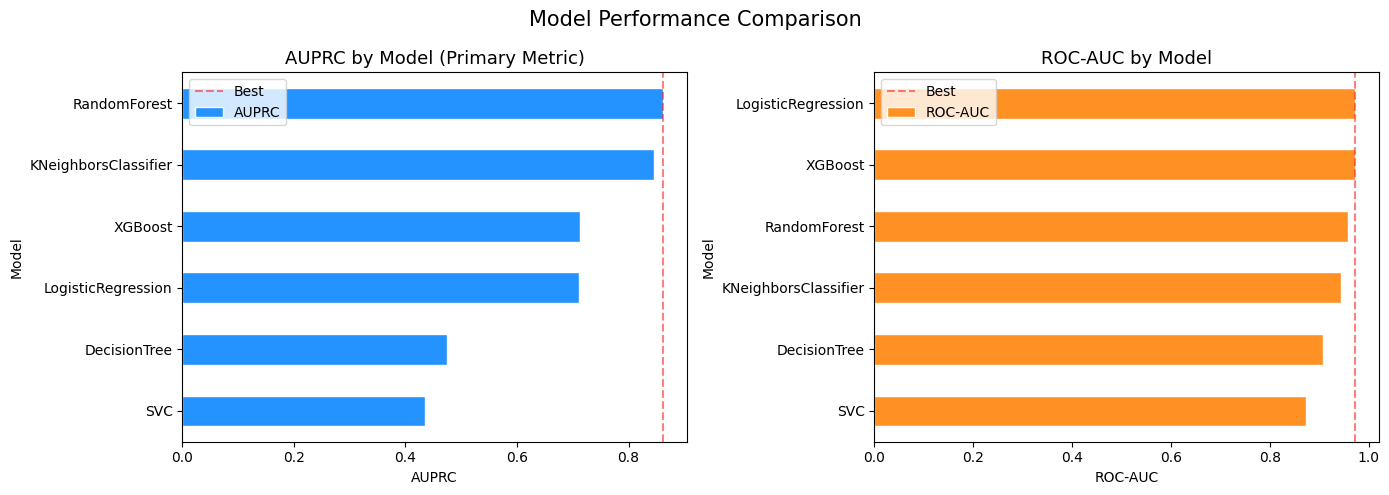

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

summary_df['AUPRC'].sort_values().plot(
    kind='barh', ax=axes[0], color='#2492ff', edgecolor='white'
)
axes[0].set_title('AUPRC by Model (Primary Metric)', fontsize=13)
axes[0].set_xlabel('AUPRC')
axes[0].axvline(summary_df['AUPRC'].max(), color='red',
                linestyle='--', alpha=0.5, label='Best')
axes[0].legend()

summary_df['ROC-AUC'].sort_values().plot(
    kind='barh', ax=axes[1], color='#ff9124', edgecolor='white'
)
axes[1].set_title('ROC-AUC by Model', fontsize=13)
axes[1].set_xlabel('ROC-AUC')
axes[1].axvline(summary_df['ROC-AUC'].max(), color='red',
                linestyle='--', alpha=0.5, label='Best')
axes[1].legend()

plt.suptitle('Model Performance Comparison', fontsize=15)
plt.tight_layout()
plt.show()

# The results

Finally we arrived at great results with no overfitting, on the whole dataset, next we will compare with relatively newer methods using Deep Learning

In [ ]:
# We are going to see how these models compare to basic deep learning models using tensorflow and keras.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [68]:

BFC = tf.keras.losses.BinaryFocalCrossentropy(
    gamma=2.0,
    alpha=0.25
)

BFC_high = tf.keras.losses.BinaryFocalCrossentropy(
    gamma=3.0,
    alpha=0.90
)

def build_mlp(input_dim, model_loss=BFC):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(128, activation='swish'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(64, activation='swish'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(32, activation='swish'),

        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer = keras.optimizers.AdamW(
        learning_rate=1e-3, 
        weight_decay=1e-5
    ),
        loss=model_loss,
        metrics=[keras.metrics.AUC(curve="PR", name="auc_pr")]
    )

    return model

def plot_training_history(history, name):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Loss plot
    axes[0].plot(history.history['loss'], label='Train Loss', color='#ff9124')
    axes[0].plot(history.history['val_loss'], label='Val Loss', color='#2492ff')
    axes[0].set_title(f'Training & Validation Loss - {name}', fontsize=14)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # AUC-PR plot
    axes[1].plot(history.history['auc_pr'], label='Train AUC-PR', color='#ff9124')
    axes[1].plot(history.history['val_auc_pr'], label='Val AUC-PR', color='#2492ff')
    axes[1].set_title(f'Training & Validation AUC-PR - {name}', fontsize=14)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('AUC-PR')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()
    
def get_callbacks(patience=25):
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_auc_pr",
            patience=patience,
            mode="max",
            restore_best_weights=True
        )
    ]

In [69]:
X_train_main, X_val, y_train_main, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

In [70]:
model = build_mlp(X_train.shape[1])
history = model.fit(
    X_train_main, y_train_main,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=2048,
    callbacks=get_callbacks(),
    verbose=1
)

model_high = build_mlp(X_train.shape[1], model_loss=BFC_high)
history_high = model_high.fit(
    X_train_main, y_train_main,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=2048,
    callbacks=get_callbacks(),
    verbose=1
)

Epoch 1/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - auc_pr: 0.2138 - loss: 0.0238 - val_auc_pr: 0.6387 - val_loss: 0.0145
Epoch 2/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc_pr: 0.5366 - loss: 0.0031 - val_auc_pr: 0.6975 - val_loss: 0.0024
Epoch 3/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc_pr: 0.5845 - loss: 0.0022 - val_auc_pr: 0.7134 - val_loss: 0.0016
Epoch 4/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc_pr: 0.6035 - loss: 0.0019 - val_auc_pr: 0.7325 - val_loss: 0.0013
Epoch 5/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc_pr: 0.6434 - loss: 0.0017 - val_auc_pr: 0.7681 - val_loss: 0.0013
Epoch 6/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc_pr: 0.7116 - loss: 0.0014 - val_auc_pr: 0.7710 - val_loss: 0.0013
Epoch 7/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc_pr: 0.7198 - loss: 0.0013 - val_auc_pr: 0.7906 - val_loss: 0.0012
Epoch 8/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc_pr: 0.7083 - loss: 0.0013 - val_auc_pr: 0.7812 - val_loss: 0.0012
Epoch 9/150
90/9

In [71]:
y_pred = model.predict(X_test).ravel()
print("MLP PR-AUC:", average_precision_score(y_test, y_pred))
print("MLP ROC-AUC:", roc_auc_score(y_test, y_pred))
y_pred_high = model_high.predict(X_test).ravel()
print("MLP HIGH PR-AUC:", average_precision_score(y_test, y_pred_high))
print("MLP HIGH ROC-AUC:", roc_auc_score(y_test, y_pred_high))

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 580us/step
MLP PR-AUC: 0.85849368415949
MLP ROC-AUC: 0.9784378122380071
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 575us/step
MLP HIGH PR-AUC: 0.860781463282589
MLP HIGH ROC-AUC: 0.9786736057675743


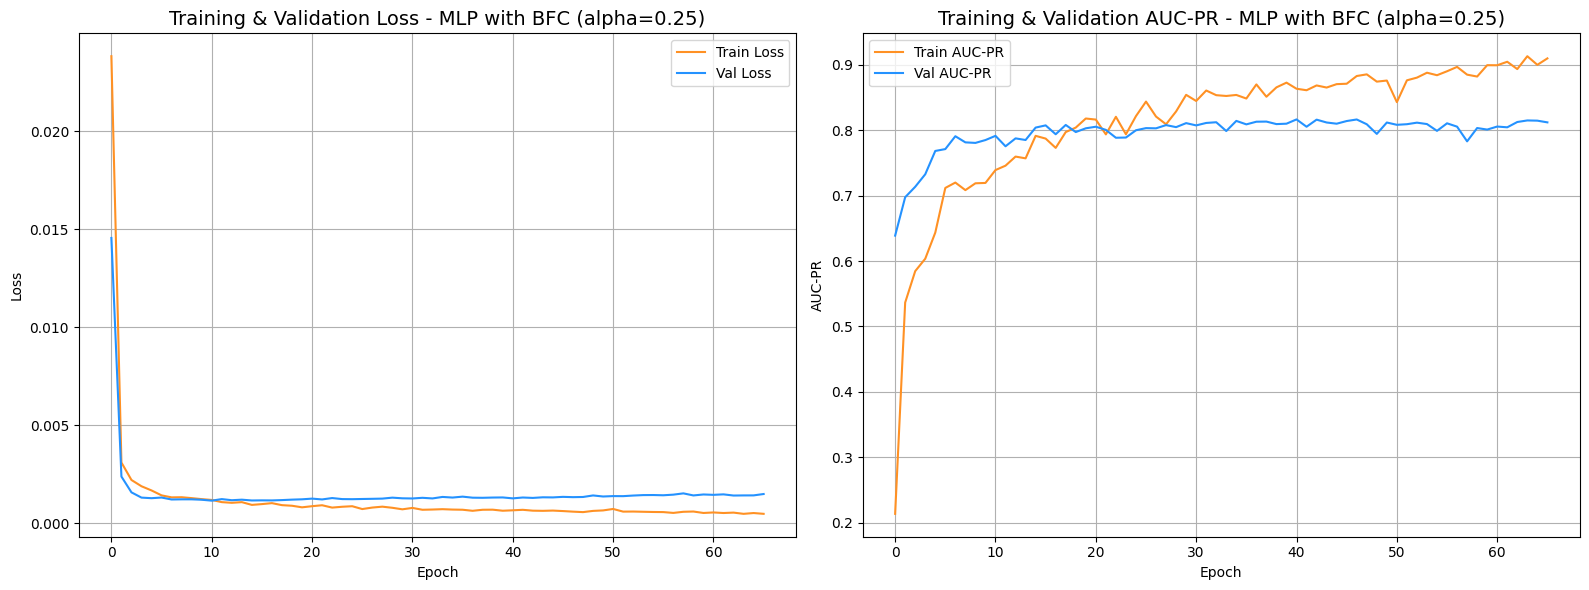

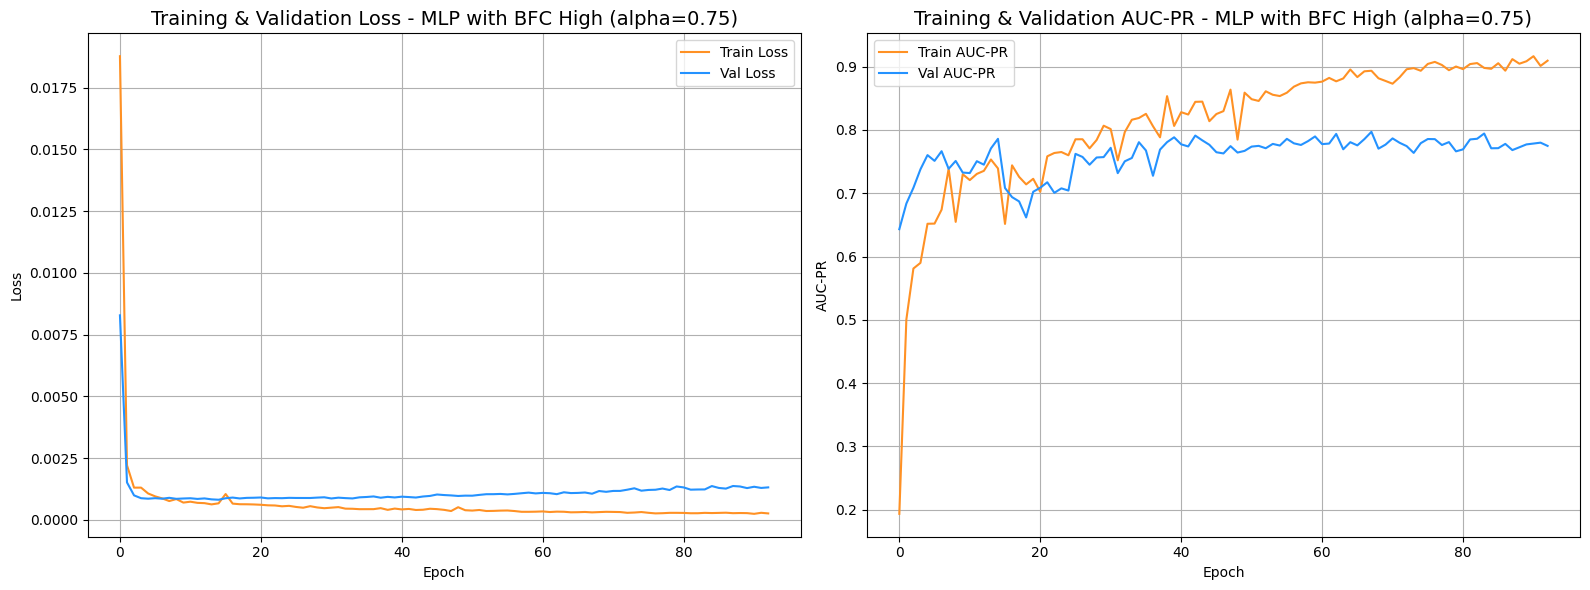

In [72]:
plot_training_history(history, "MLP with BFC (alpha=0.25)")
plot_training_history(history_high, "MLP with BFC High (alpha=0.75)")

In [73]:
import random
def set_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

In [ ]:
results_log = []
def run_experiment(model_name, model_builder, X_train, y_train, X_val, y_val, y_test,
                   epochs=200, batch_size=2048, verbose=0, patience=30, callbackAnnealing=False):
    print(f"\n{'='*55}")
    print(f"  Starting: {model_name}")
    print(f"{'='*55}")

    start = time.time()
    model = model_builder(X_train.shape[1])
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=get_callbacks(patience=patience),
        verbose=verbose
    )
    
    y_pred = model.predict(X_test).ravel()
    duration  = time.time() - start
    best_auprc = max(history.history['val_auc_pr'])
    avg_PRAUC = average_precision_score(y_test, y_pred)

    results_log.append({
        "Model": model_name,
        "Val AUC-PR": round(best_auprc, 4),
        "Pred AUC-PR": round(avg_PRAUC, 4),
        "Train Time (sec)": round(duration, 2),
        "Epochs Run": len(history.history['loss'])
    })

    plot_training_history(history, name=model_name)
    print(f"  Best val_auc_pr: {best_auprc:.4f}")
    print(f"  Test AUC-PR: {avg_PRAUC:.4f}")
    return model, history



  Starting: MLP-RELU
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 463us/step


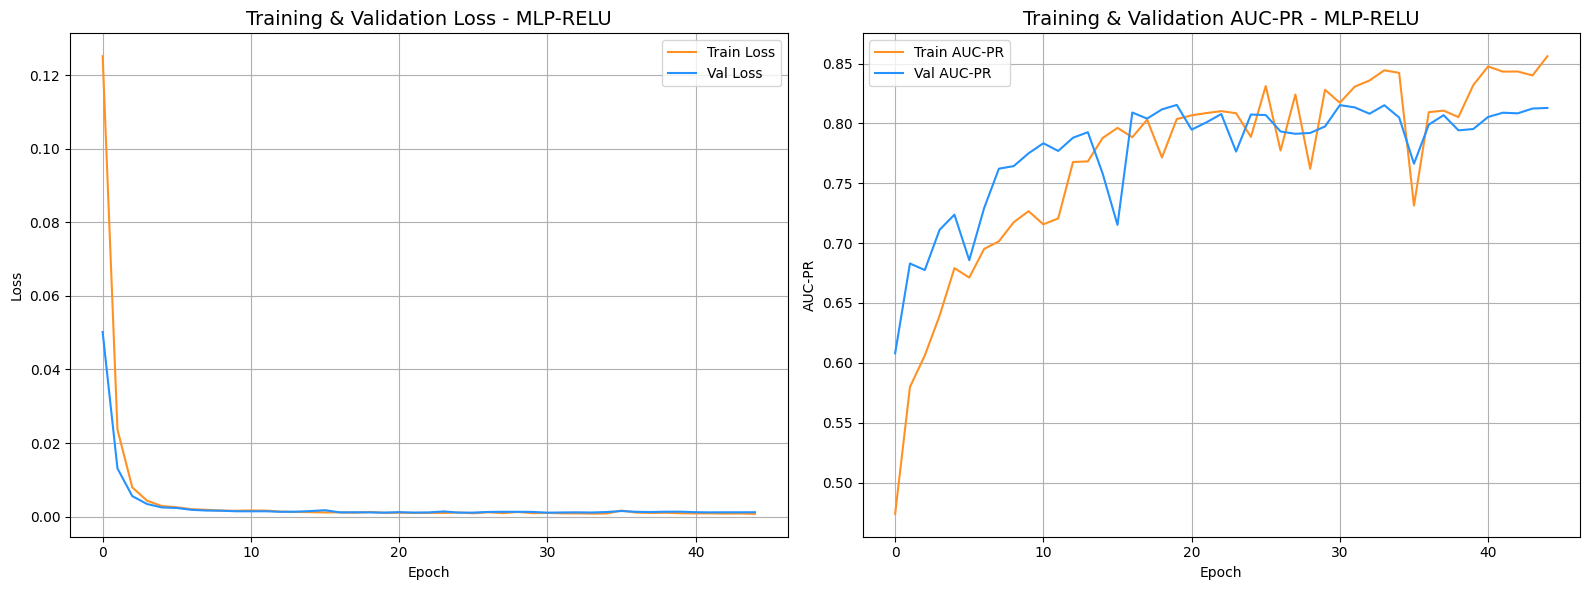

  Best val_auc_pr: 0.8155
  Test AUC-PR: 0.8560

  Starting: MLP-SWISH
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 426us/step


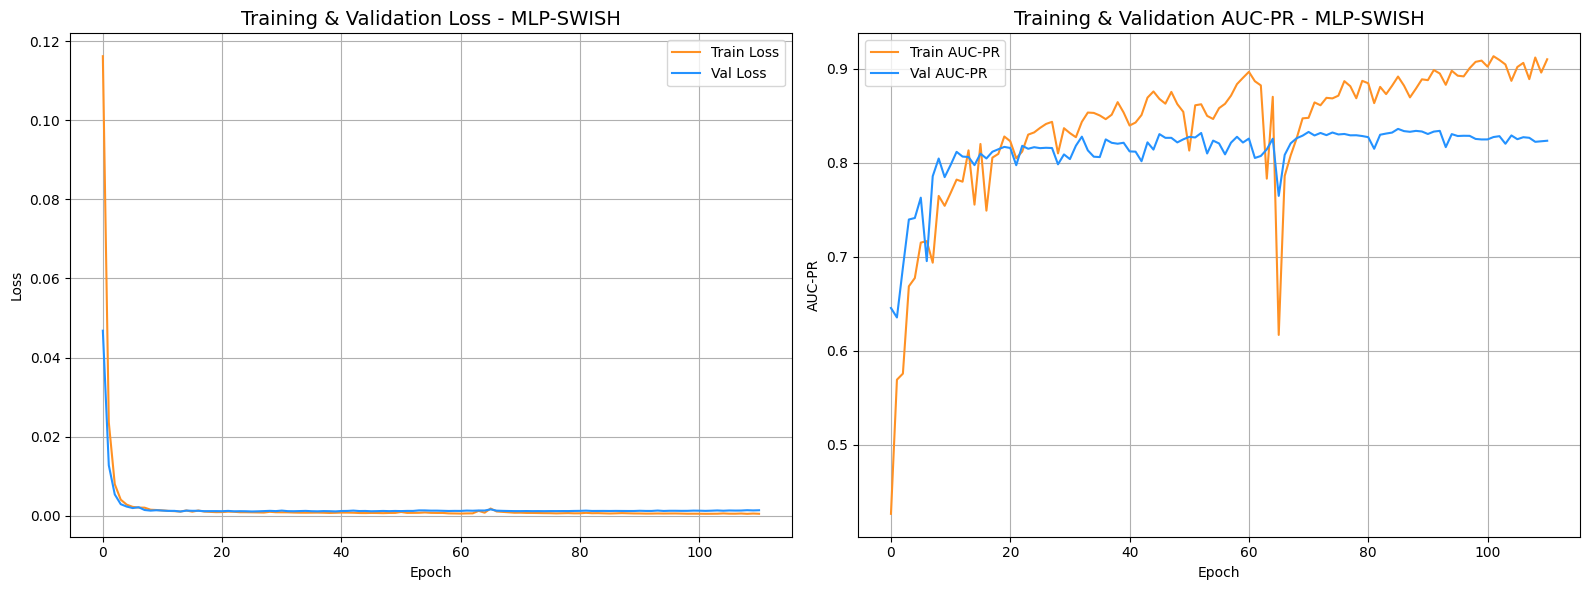

  Best val_auc_pr: 0.8359
  Test AUC-PR: 0.8640

  Starting: MLP-GELU
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 397us/step


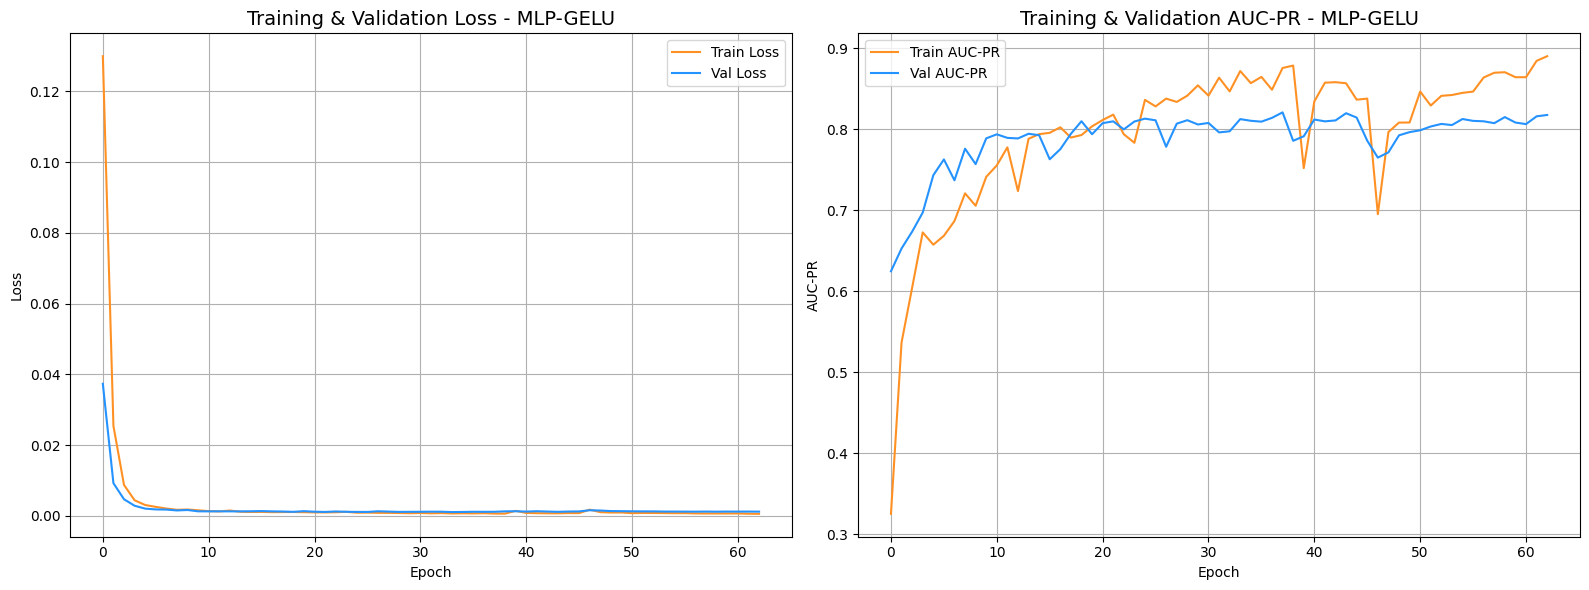

  Best val_auc_pr: 0.8210
  Test AUC-PR: 0.8600
Results:
       Model  Val AUC-PR  Pred AUC-PR  Train Time (sec)  Epochs Run
0   MLP-RELU      0.8155        0.856             21.11          45
1  MLP-SWISH      0.8359        0.864             53.42         111
2   MLP-GELU      0.8210        0.860             28.84          63


In [ ]:
def build_mlp_variant(input_dim, activation_type):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation=activation_type),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation=activation_type),
        layers.BatchNormalization(),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer = keras.optimizers.AdamW(
        learning_rate=1e-3, 
        weight_decay=1e-5
    ),
        loss=BFC,
        metrics=[keras.metrics.AUC(curve="PR", name="auc_pr")]
    )
    return model

results = []
for act in ['relu', 'swish', 'gelu']:
    start = time.time()
    m_func = lambda dim: build_mlp_variant(dim, act)
    run_experiment(f"MLP-{act.upper()}", m_func, X_train_main, y_train_main, X_val, y_val, y_test, verbose=0, epochs=150, patience=25)

print(f"Results:\n{pd.DataFrame(results_log)}")

Class weights: {0: np.float64(0.5008661206149896), 1: np.float64(289.14340101522845)}

  Starting: MLP
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 570us/step


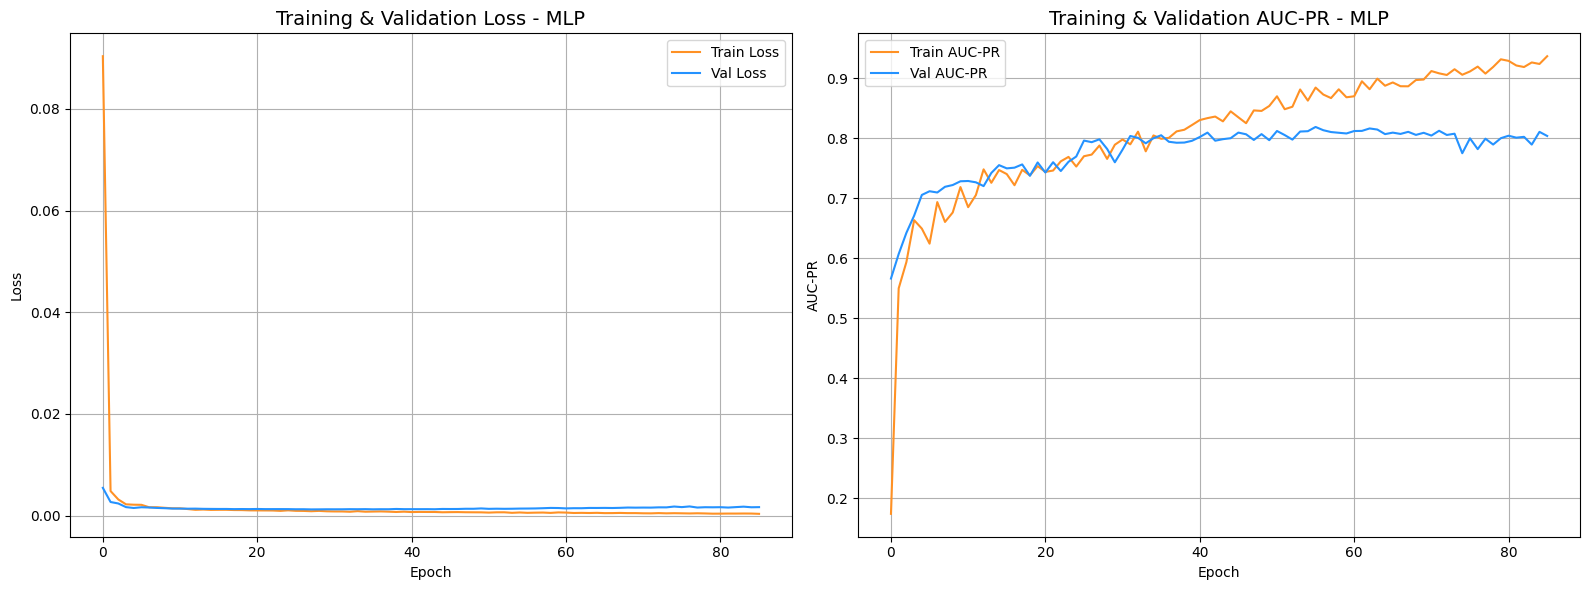

  Best val_auc_pr: 0.8188
  Test AUC-PR: 0.8634

  Starting: Residual MLP
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 685us/step


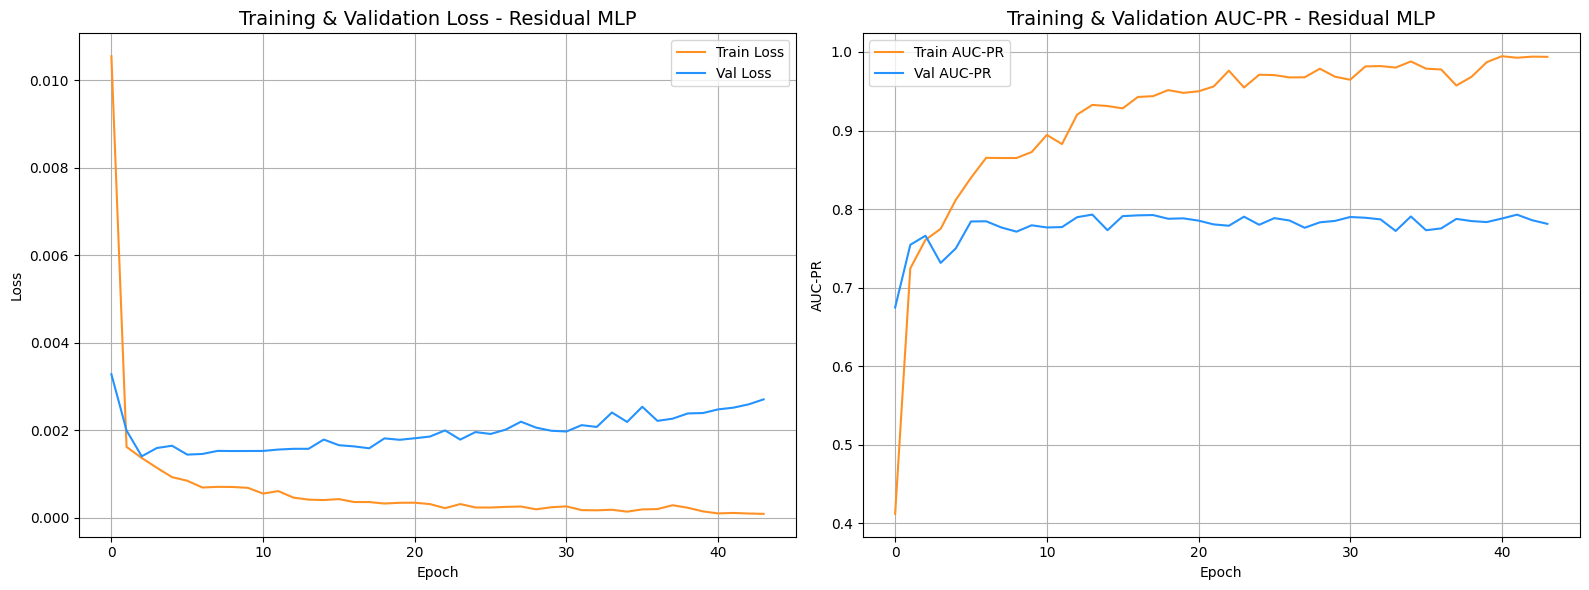

  Best val_auc_pr: 0.7929
  Test AUC-PR: 0.8347

  Starting: FT-Transformer
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step


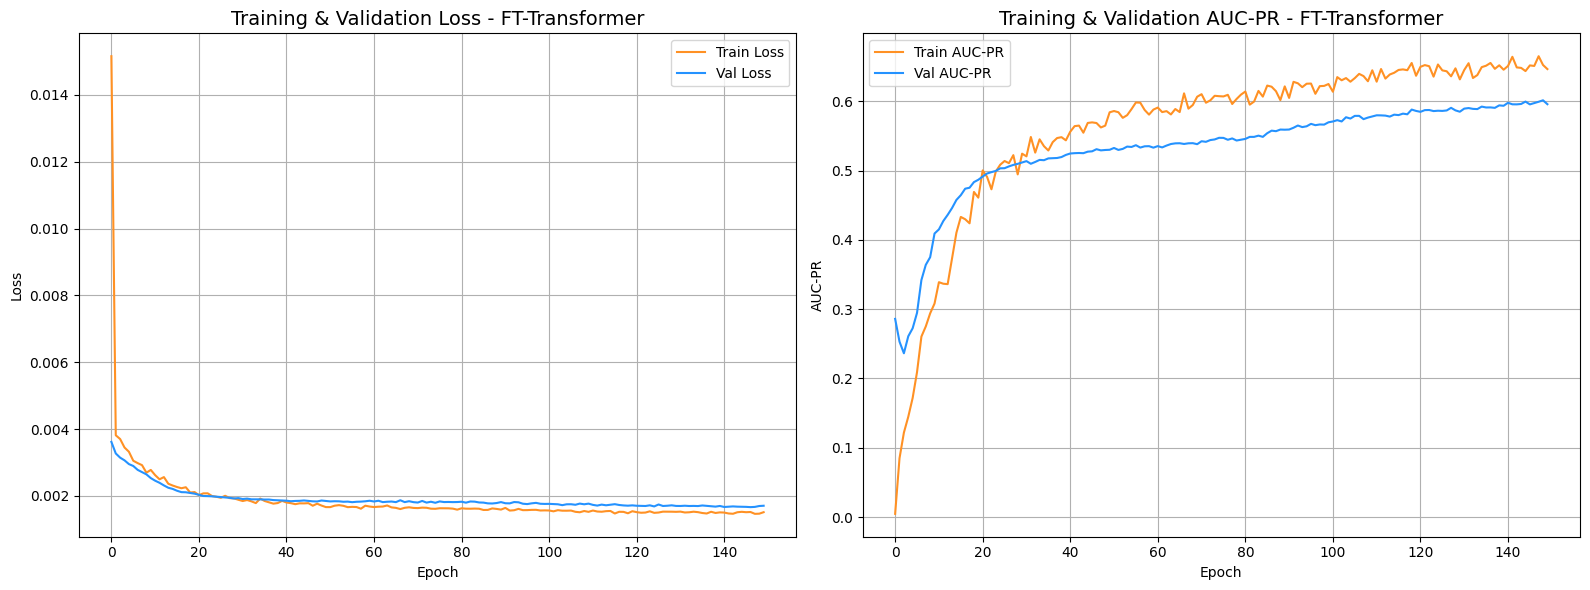

  Best val_auc_pr: 0.6013
  Test AUC-PR: 0.6381

  Starting: Ensemble (5x MLP)

  Ensemble model 1/5

  Ensemble model 2/5

  Ensemble model 3/5

  Ensemble model 4/5

  Ensemble model 5/5
 Ensemble val_auc_pr: 0.7419

═══════════════════════════════════════════════════════
  FINAL LEADERBOARD
═══════════════════════════════════════════════════════
               Model  Val AUC-PR  Pred AUC-PR  Train Time (sec) Epochs Run
1                MLP      0.8188       0.8634             63.02         86
2       Residual MLP      0.7929       0.8347             42.43         44
3  Ensemble (5x MLP)      0.7419          NaN            372.59        N/A
4     FT-Transformer      0.6013       0.6381           7970.70        150

★  Best model: MLP  (AUC-PR: 0.8188)


In [ ]:
def set_seeds(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

BFC = tf.keras.losses.BinaryFocalCrossentropy(
    gamma=2.0,
    alpha=0.75
)

class CosineAnnealingWithWarmRestarts(keras.callbacks.Callback):
    """
    Cosine annealing with warm restarts (SGDR).
    T_0: initial cycle length in epochs
    T_mult: cycle length multiplier after each restart
    eta_min: minimum learning rate floor
    """
    def __init__(self, T_0=20, T_mult=2, eta_min=1e-6, eta_max=1e-3):
        super().__init__()
        self.T_0 = T_0
        self.T_mult = T_mult
        self.eta_min = eta_min
        self.eta_max = eta_max
        self.T_cur = 0
        self.T_i = T_0

    def on_epoch_begin(self, epoch, logs=None):
        lr = self.eta_min + 0.5 * (self.eta_max - self.eta_min) * (
            1 + np.cos(np.pi * self.T_cur / self.T_i)
        )
        self.model.optimizer.learning_rate.assign(lr)

    def on_epoch_end(self, epoch, logs=None):
        self.T_cur += 1
        if self.T_cur >= self.T_i:
            self.T_cur = 0
            self.T_i = int(self.T_i * self.T_mult)  # extend cycle

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class weights: {class_weight_dict}")

def get_callbacks_annealing(patience=30):
    return [
        keras.callbacks.EarlyStopping(
            monitor='val_auc_pr',
            patience=patience,
            mode='max',
            restore_best_weights=True
        ),
        CosineAnnealingWithWarmRestarts(
            T_0=20,
            T_mult=2,
            eta_min=1e-6,
            eta_max=1e-3
        )
    ]

def build_mlp(input_dim):
    set_seeds()
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(256, activation='swish', kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(128, activation='swish', kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(64, activation='swish', kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(32, activation='swish', kernel_initializer='he_normal'),

        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-5),
        loss=BFC,
        metrics=[keras.metrics.AUC(curve="PR", name="auc_pr")]
    )
    return model

def build_ft_transformer(input_dim, num_heads=4, embed_dim=32, depth=3):
    set_seeds()
    inputs = layers.Input(shape=(input_dim,))
    x = layers.Reshape((input_dim, 1))(inputs)
    tokens = layers.Dense(embed_dim)(x)

    for _ in range(depth):
        attn_output = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim,
            dropout=0.2
        )(tokens, tokens)
        out1 = layers.LayerNormalization(epsilon=1e-6)(tokens + attn_output)
        ffn_output = keras.Sequential([
            layers.Dense(embed_dim * 2, activation='swish'),
            layers.Dropout(0.2),
            layers.Dense(embed_dim),
        ])(out1)
        tokens = layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

    x = layers.GlobalAveragePooling1D()(tokens)
    x = layers.Dense(64, activation='swish')(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-5),
        loss=BFC,
        metrics=[keras.metrics.AUC(curve="PR", name="auc_pr")]
    )
    return model

def build_residual_mlp(input_dim):
    set_seeds()
    inputs = layers.Input(shape=(input_dim,))

    x = layers.Dense(128, activation='swish', kernel_initializer='he_normal')(inputs)
    x = layers.BatchNormalization()(x)

    residual = x
    x = layers.Dense(128, activation='swish', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([x, residual])
    x = layers.Activation('swish')(x)

    residual = x
    x = layers.Dense(128, activation='swish', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(128, kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([x, residual])
    x = layers.Activation('swish')(x)

    x = layers.Dense(32, activation='swish')(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-5),
        loss=BFC,
        metrics=[keras.metrics.AUC(curve="PR", name="auc_pr")]
    )
    return model

def plot_training_history_color(history, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(title, fontsize=15)

    axes[0].plot(history.history['loss'],     label='Train Loss', color='#ff9124')
    axes[0].plot(history.history['val_loss'], label='Val Loss',   color='#2492ff')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['auc_pr'],     label='Train AUC-PR', color='#ff9124')
    axes[1].plot(history.history['val_auc_pr'], label='Val AUC-PR',   color='#2492ff')
    axes[1].set_title('AUC-PR')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

results_log = []

def train_ensemble(X_train, y_train, input_dim, num_models=5):
    models = []
    
    X_np = X_train.values if hasattr(X_train, 'values') else X_train
    y_np = y_train.values if hasattr(y_train, 'values') else y_train
    n = len(X_np)

    for i in range(num_models):
        print(f"\n  Ensemble model {i+1}/{num_models}")
        set_seeds(seed=i)

        idx = np.random.choice(n, size=n, replace=True)
        X_sample = X_np[idx]
        y_sample = y_np[idx]

        model = build_mlp(input_dim)
        model.fit(
            X_sample, y_sample,
            epochs=150,
            batch_size=2048,
            validation_split=0.1,
            class_weight=class_weight_dict,
            callbacks=get_callbacks_annealing(),
            verbose=0
        )
        models.append(model)

    return models

def predict_ensemble(models, X):
    preds = np.array([m.predict(X, verbose=0).ravel() for m in models])
    return preds.mean(axis=0)

mlp_model, history_mlp = run_experiment("MLP", build_mlp,X_train_main, y_train_main, X_val, y_val, y_test, epochs=150, patience=30, verbose=0)
residual_model, history_res = run_experiment("Residual MLP", build_residual_mlp,  X_train_main, y_train_main, X_val, y_val, y_test, epochs=150, patience=30, verbose=0)
transformer_model, history_trans = run_experiment("FT-Transformer", build_ft_transformer, X_train_main, y_train_main, X_val, y_val, y_test, epochs=150, patience=30, verbose=0)

print(f"\n{'='*55}")
print("  Starting: Ensemble (5x MLP)")
print(f"{'='*55}")
start = time.time()
ensemble_models = train_ensemble(X_train_main, y_train_main, X_train_main.shape[1], num_models=5)
y_pred_ens = predict_ensemble(ensemble_models, X_test)
pr_metric = keras.metrics.AUC(curve="PR")
pr_metric.update_state(y_test, y_pred_ens)
ens_score = pr_metric.result().numpy()
results_log.append({
    "Model": "Ensemble (5x MLP)",
    "Val AUC-PR": round(float(ens_score), 4),
    "Train Time (sec)": round(time.time() - start, 2),
    "Epochs Run": "N/A"
})
print(f" Ensemble val_auc_pr: {ens_score:.4f}")

results_df = (pd.DataFrame(results_log)
                .sort_values("Val AUC-PR", ascending=False)
                .reset_index(drop=True))

results_df.index += 1 # start index at 1 for nicer display
print("\n" + "═"*55)
print("  FINAL LEADERBOARD")
print("═"*55)
print(results_df.to_string())
print(f"\n  Best model: {results_df.iloc[0]['Model']}  "
      f"(AUC-PR: {results_df.iloc[0]['Val AUC-PR']:.4f})")

# The results and comparison

The Deep Learning method required much less interaction with the data itself and, in our case specifically, ended up giving us a model on par, or better than, our best previous ML model. As was shown on the training curves, the FT-Transformer could get much better with more training time, but it isn't guaranteed to exceed our best MLP model due to how the data is structured.

## Data used

The dataset that was used is the [Credit Card Fraud Dataset](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) from Kaggle.